In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
NUM_CORES = 16
DEFAULT_MIN_MAPQ = 10
DEFAULT_MAX_FRAG_LEN = 511

import os
import tqdm

import pandas as pd
import seaborn

from fbio.dataframe import RegionDataFrame, DataFrameBase
from fragments_h5.fragments_h5 import FragmentsH5

from ravel.fragment_array import RegionFragmentArray, FragmentMatrix, Region, merge_fragment_arrays

from ravel.bio.features import load_gene_expression_df
from ravel.public_data_resources.roadmap import CELL_ANATOMY_TO_CELL_EID

/tmp/ipykernel_21845/960331892.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
import pandas

class SampleDataFrame(DataFrameBase):
    def __init__(self, data, *args, **kwargs):
        super().__init__(data, *args, **kwargs)

        # hack around pandas not correctly using _constructor internally
        # This line should always be first.  Pandas incorrectly passes this BlockManager to the constructor sometimes.
        if isinstance(data, pandas.core.internals.BlockManager):
            return

        if "sample_id" not in self.columns:
            raise ValueError("SampleDataFrame must have a sample_id column")

        if "frag_h5" not in self.columns:
            raise ValueError("SampleDataFrame must have a frag_h5 column")

        return

# Load Sample DF

In [4]:
def load_crc_sample_df():
    label_mapping = {'Neg': 1, 'AA': 2, 'CRC-I': 3, 'CRC-II': 4, 'CRC-III': 5}
    sample_df = pd.read_csv("/scratch/karius/CRC/Pooled_CRC_Meta_df.csv")[['SampleID', 'library_name', 'seqrun_name', 'Disease_disease_label', 'Disease_stage', 'Disease_description']]
    sample_df = sample_df.rename(columns={'SampleID': 'sample_id'}).fillna('').set_index('sample_id')
    sample_df = sample_df.assign(frag_h5_path="/scratch/karius/CRC/frag_h5s/CRC." + sample_df.library_name + "_" + sample_df.seqrun_name + ".fragments.h5").drop(columns=['library_name', 'seqrun_name'])
    sample_df = sample_df.assign(label = sample_df.apply(lambda x: x.Disease_disease_label + ("" if x.Disease_stage == '' else '-' + x.Disease_stage.split()[0].replace("IIA", "II")), 1)).drop(columns=['Disease_disease_label', 'Disease_stage'])
    sample_df = sample_df.assign(label = sample_df.apply(lambda x: str(label_mapping[x.label]) + "-" + x.label, 1))
    sample_df = sample_df.assign(frag_h5 = sample_df.apply(lambda x: FragmentsH5(x.frag_h5_path), 1))
    return SampleDataFrame(sample_df.reset_index()[['sample_id', 'label', 'frag_h5', 'Disease_description']])

In [5]:
import glob

def load_ibd_sample_df():
    label_mapping = {'Remission': 1, 'Mild': 2, 'Moderate': 3, 'Severe': 4}

    sample_ids_to_samples = {}
    for fname in glob.glob("/scratch/karius/*.fragments.h5"):
        sample_id = fname.split("/")[3].split('.')[1].split('_')[0][:-5]
        sample_ids_to_samples[sample_id] = fname

    assert 1 == pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")["SampleID"].value_counts().max()
    metadata = pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")
    metadata = metadata.query("SampleID in @sample_ids_to_samples.keys()")[['SampleID', 'DIAGNOSIS', 'ENDO_CATEGORY', 'Cluster', 'SITE_NUMBER']].rename(columns={"SampleID": 'sample_id'})
    metadata = metadata.assign(label = metadata.apply(lambda x: label_mapping[x.ENDO_CATEGORY], 1))
    metadata = metadata.assign(frag_h5 = metadata.apply(lambda x: FragmentsH5(sample_ids_to_samples[x.sample_id]), 1))[['sample_id', 'label', 'frag_h5', 'DIAGNOSIS', 'ENDO_CATEGORY', 'Cluster', 'SITE_NUMBER']]
    return SampleDataFrame(metadata).sort_values('label')

In [6]:
import seaborn as sns
import numpy as np

def plot_and_load_ref_fl_dist(sample_df):
    max_frag_len = 512
    sns.set(rc={'figure.figsize':(20, 8)})
    columns = {}
    for frag_h5 in sample_df.frag_h5:
        cnts = frag_h5.fragment_length_counts[:max_frag_len]
        # normalize to library depth
        cnts = cnts/cnts.sum()
        columns['RD-' + frag_h5.sample_id.split('-')[1]] = cnts

    fl_df = pd.DataFrame(columns)
    fl_df = fl_df.set_index(fl_df.index+1)

    ref_fl_dist = fl_df.mean(axis=1)
    ref_fl_dist = ref_fl_dist/ref_fl_dist.sum()

    color_mapping = {5: 'red', 4: 'orange', 3: 'yellow', 2: 'green', 1: 'blue'}
    colors = [color_mapping[x] for x in sample_df.label.tolist()]

    fl_df.loc[:, 'Reference'] = ref_fl_dist
    colors.append('black')

    fl_df.plot(color=colors, legend=False)

    return fl_df.drop(columns='Reference'), ref_fl_dist, color_mapping

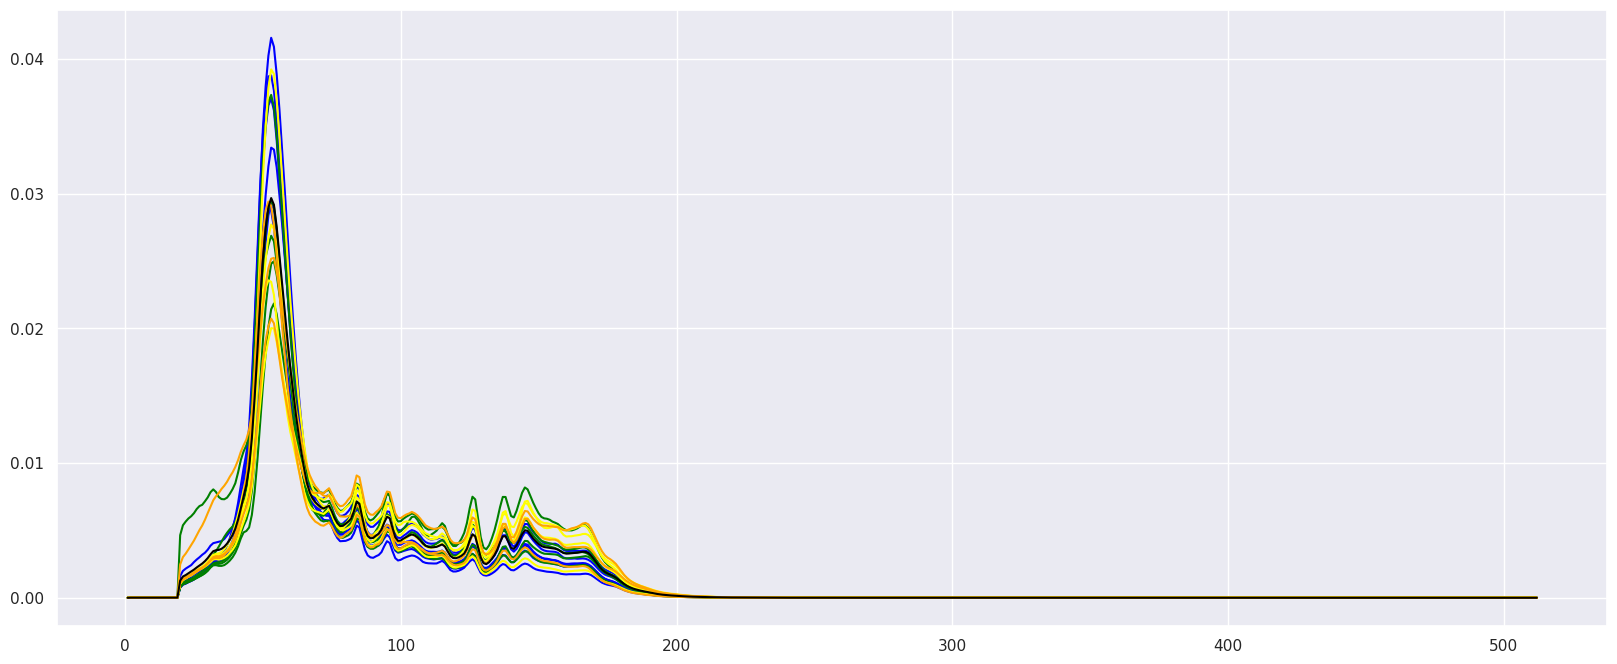

In [11]:
sample_df = load_ibd_sample_df()
fl_df, ref_fl_dist, color_mapping = plot_and_load_ref_fl_dist(sample_df)

In [12]:
fl_df

,RD-56170,RD-56169,RD-56168,RD-56167,RD-56165,RD-56166,RD-56150,RD-56153,RD-56154,RD-56155,RD-56156,RD-56164,RD-56163,RD-56162,RD-56161,RD-56171,RD-56172,RD-56173
1,6.458258e-07,5.074389e-07,9.381237e-07,5.385034e-07,0.000001,0.000001,0.000001,5.624770e-07,6.608165e-07,9.024162e-07,6.058446e-07,6.005924e-07,4.314227e-07,0.000001,6.969642e-07,0.000001,5.949151e-07,6.031787e-07
2,1.173747e-05,1.170248e-05,8.099780e-06,6.223323e-06,0.000038,0.000017,0.000011,7.816989e-06,1.052197e-05,6.112242e-06,1.248852e-05,6.969952e-06,4.267526e-06,0.000012,1.595073e-05,0.000009,9.622370e-06,5.553619e-06
3,1.062135e-05,1.089686e-05,7.538840e-06,5.496066e-06,0.000036,0.000016,0.000010,7.488156e-06,8.747303e-06,5.200522e-06,1.092706e-05,6.098323e-06,3.960638e-06,0.000011,1.504070e-05,0.000007,8.945082e-06,4.966067e-06
4,1.078032e-05,1.128659e-05,7.780624e-06,6.004036e-06,0.000038,0.000015,0.000009,7.237205e-06,9.397900e-06,5.754066e-06,1.190766e-05,6.803634e-06,4.125201e-06,0.000012,1.578461e-05,0.000007,9.549150e-06,5.584872e-06
5,1.158512e-05,1.208175e-05,8.534992e-06,6.237202e-06,0.000040,0.000017,0.000010,7.727569e-06,1.059350e-05,5.637776e-06,1.266653e-05,6.966872e-06,4.452104e-06,0.000012,1.678853e-05,0.000008,1.029051e-05,6.038037e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,1.414193e-06,1.467388e-06,1.141223e-06,9.854058e-07,0.000003,0.000002,0.000001,9.663067e-07,1.216039e-06,9.210227e-07,1.439662e-06,1.059507e-06,7.672207e-07,0.000002,1.783939e-06,0.000002,1.168474e-06,7.625679e-07
509,1.195606e-06,1.470003e-06,1.112209e-06,9.493205e-07,0.000003,0.000002,0.000001,1.021112e-06,1.318227e-06,9.256744e-07,1.630159e-06,9.886675e-07,7.427586e-07,0.000001,1.841719e-06,0.000001,1.134915e-06,7.469415e-07
510,1.374450e-06,1.443847e-06,1.262115e-06,9.715268e-07,0.000003,0.000002,0.000001,1.110532e-06,1.222851e-06,7.814738e-07,1.367835e-06,8.901088e-07,7.805637e-07,0.000001,1.910332e-06,0.000001,1.333220e-06,8.219481e-07
511,1.122743e-06,1.307832e-06,1.010659e-06,1.004836e-06,0.000003,0.000002,0.000001,9.259238e-07,1.434040e-06,9.628874e-07,1.458399e-06,9.455481e-07,7.027297e-07,0.000001,1.599768e-06,0.000001,1.220339e-06,8.188229e-07


# Load Region DF

In [13]:
def load_gencode_rdf():
    gencode_rdf = pd.read_table(
        "/scratch/nboley/gencode/gencode.v39.basic.annotation.protein_coding.gff3",
        usecols=[0, 2, 3, 4, 6, 8],
        names=["contig", "element", "start", "stop", "strand", "meta"],
    ).query("contig not in ['chrM', 'chrY'] and element in ['three_prime_UTR', 'five_prime_UTR']") # 'gene', 'transcript', 'exon', 
    gencode_rdf['gene_id'] = gencode_rdf.meta.str.extract(';gene_id=(ENSG?\d+)\.\d+;')
    gencode_rdf['gene_name'] = gencode_rdf.meta.str.extract(';gene_name=(.+?);')
    gencode_rdf = gencode_rdf.drop(columns=['meta'])
    gencode_rdf = gencode_rdf.drop_duplicates()
    return RegionDataFrame(gencode_rdf.sort_values(["contig", "start"]), ref='hg38')

def load_genes_rdf():
    _rdf = load_gencode_rdf()

    tes_s = []
    for idx, sub_df in _rdf.query(f"strand == '+' and element == 'three_prime_UTR'").groupby('gene_id')['stop']:
        tes_s.append([idx, sub_df.agg(lambda x: pd.Series.mode(x)[0])])
    for idx, sub_df in _rdf.query(f"strand == '-' and element == 'three_prime_UTR'").groupby('gene_id')['start']:
        tes_s.append([idx, sub_df.agg(lambda x: pd.Series.mode(x)[0])])

    tss_s = []
    for idx, sub_df in _rdf.query(f"strand == '+' and element == 'five_prime_UTR'").groupby('gene_id')['start']:
        tss_s.append([idx, sub_df.agg(lambda x: pd.Series.mode(x)[0])])
    for idx, sub_df in _rdf.query(f"strand == '-' and element == 'five_prime_UTR'").groupby('gene_id')['stop']:
        tss_s.append([idx, sub_df.agg(lambda x: pd.Series.mode(x)[0])])

    tss_and_tes = pd.DataFrame(tss_s, columns=['gene_id', 'tss']).set_index('gene_id').join(pd.DataFrame(tes_s, columns=['gene_id', 'tes']).set_index('gene_id')).dropna().astype(int)
    # return tss_and_tes, _rdf # .set_index('gene_id')[['contig', 'strand']]

    _rdf = _rdf[['gene_id', 'gene_name', 'contig', 'strand']].drop_duplicates().set_index('gene_id').join(tss_and_tes, how='inner')
    _rdf['start'] = pd.DataFrame(_rdf)[['tss', 'tes']].min(axis=1)
    _rdf['stop'] = pd.DataFrame(_rdf)[['tss', 'tes']].max(axis=1)
    
    return _rdf

In [14]:

from itertools import chain

"""
Cluster	scRNA

1	HSC - Hematopoietic Stem Cells
* 2	Early Eryth. - Early Erythroid Cells
* 3	Late Eryth. - Late Erythroid Cells
4	Early Basophil Cells
* 5	CMP/LMPP - Common Myeloid Progenitor / lymphoid-primed multipotent progenitors
* 6	CLP 1 - Common Lymphoid Progenitor
* 7	GMP - Granulocyte-Monocyte progenitors
* 8	GMP/Neut - Granulocyte-Monocyte progenitors / Neutrophil
9	pDC - Plasmacytoid Dendritic Cell
10	cDC - Classical Dendritic CElls
* 11	CD14 Mono 1 - CD14+ Monocyte Cells
* 12	CD14 Mono 2 - CD14+ Monocyte Cells
* 13	CD16 Mono - CD16+ Monocyte Cells
14	Unk - Unkown
* 15	CLP 2 - Common Lymphoid Progenitor
16	Pre B - Pre B-Cell Progenitor
17	B - B Cells
18	Plasma - Plasma Cells
19	CD8 N - CD8+ Naïve Cells
20	CD4 N 1 - CD4+ Naïve Cells
21	CD4 N 2 - CD4+ Naïve Cells
22	CD4 M - CD4+ Memory Cells
23	CD8 EM - CD8+ Effector Memory Cells
24	CD8 CM - CD8+ Central Memory Cells
25	NK - Natural Killer Cells
26	Unk - Unkown
"""

cluster_names_and_weights = """
Early_Erythroid_Cells 0.17
Late_Erythroid_Cells 0.15
Myeloid_Progenitor 0.1
Lymphoid_Progenitor_1 0.08
Granulocyte-Monocyte_Progenitor 0.16
Neutrophil 0.21
CD14+_Monocyte_Cells_1 0.05
CD14+_Monocyte_Cells_2 0.04
CD16+_Monocyte_Cells 0.04
Lymphoid_Progenitor_2 0.08
""".strip().split("\n")
cluster_names_and_weights = dict((x.split()[0], float(x.split()[1])) for x in cluster_names_and_weights)

def load_SC_RNA_labeled_genes():
    """
    
    """
    # load the raw scRNA-Seq counts, normalize buy depth, and then join with the gencode annotation
    res = pd.read_pickle("/scratch/karius/reference/sc_rnaseq.pickle")
    grpd_counts = res.groupby(by=[x.split('_')[0] for x in res.columns], axis=1).sum()
    
    tpms = grpd_counts/(grpd_counts.sum()/1e6)
    tpms = tpms[['02', '03', '05', '06', '07', '08', '11', '12', '13', '15']]
    # taking advantage of dict keys remaining sorted
    tpms.columns = list(cluster_names_and_weights.keys())
    
    gencode_rdf = load_genes_rdf()

    # join the tpms to gencode genes
    tpms = gencode_rdf.reset_index().set_index('gene_name').join(tpms).drop(columns=['tss', 'tes']).reset_index().rename(columns={'index': 'gene_name'}).set_index(['gene_name', 'gene_id', 'contig', 'strand', 'start', 'stop']).dropna()

    # make a conservative label set
    label = np.empty(tpms.shape[0], dtype='U3')
    label[tpms.max(axis=1) < 1e-6] = 'off'
    label[tpms.min(axis=1) > 5] = 'on'
    on_off_rdf = RegionDataFrame(pd.DataFrame(label, index=tpms.index, columns=['label']).query("label != ''").reset_index(), ref='hg38')

    # set expression by taking a weighted sum over the relevant sub-types
    expression_rdf = RegionDataFrame(pd.DataFrame(np.matmul(tpms.values, np.array(list(cluster_names_and_weights.values()))), index=tpms.index, columns=['expression']).reset_index(), ref='hg38')

    
    gene_expression = load_gene_expression_df('hg38')
    gi_cell_eids = sorted(x for x in set(chain(*[CELL_ANATOMY_TO_CELL_EID[x] for x in ['gi_colon',]])) if x in gene_expression.columns)
    expression_rdf = expression_rdf.set_index('gene_id').join(gene_expression.set_index('ens_id')[gi_cell_eids].mean(axis=1).rename('gi_expression')).rename(columns={'expression': 'blood_expression'}).dropna()

    return expression_rdf.reset_index()

load_genes_and_expression_rdf = load_SC_RNA_labeled_genes

In [15]:
%%time
labeled_genes = load_genes_and_expression_rdf()

WARNING	2024-02-22 07:41:53,227	/tmp/ipykernel_21845/1439167852.py:56: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grpd_counts = res.groupby(by=[x.split('_')[0] for x in res.columns], axis=1).sum()



CPU times: user 1min 23s, sys: 1.14 s, total: 1min 24s
Wall time: 1min 25s


In [16]:
labeled_genes

,gene_id,gene_name,contig,strand,start,stop,blood_expression,gi_expression
0,ENSG00000186092,OR4F5,chr1,+,65419,71585,0.000000,0.000
1,ENSG00000187634,SAMD11,chr1,+,923923,944574,0.844936,2.444
2,ENSG00000188976,NOC2L,chr1,-,944203,959256,71.417213,31.741
3,ENSG00000187961,KLHL17,chr1,+,960584,965719,2.258517,4.865
4,ENSG00000187583,PLEKHN1,chr1,+,966482,975008,0.242560,1.120
...,...,...,...,...,...,...,...,...
17322,ENSG00000277150,F8A3,chrX,-,155456914,155458620,0.000000,0.000
17323,ENSG00000185973,TMLHE,chrX,-,155489011,155545277,14.875581,3.919
17324,ENSG00000168939,SPRY3,chrX,+,155612588,155776795,0.918662,0.528
17325,ENSG00000124333,VAMP7,chrX,+,155881345,155943769,43.414360,23.092


# Build Sample and Region DataFrame

In [17]:
import pandas
from joblib import Parallel, delayed

class SampleAndRegionDataFrame(RegionDataFrame):
    def __init__(self, data, *args, **kwargs):
        super().__init__(data, *args, **kwargs)

        # hack around pandas not correctly using _constructor internally
        # This line should always be first.  Pandas incorrectly passes this BlockManager to the constructor sometimes.
        if isinstance(data, pandas.core.internals.BlockManager):
            return

        if "sample_id" not in self.columns:
            raise ValueError("SampleDataFrame must have a sample_id column")

        if "frag_h5" not in self.columns:
            raise ValueError("SampleDataFrame must have a frag_h5 column")


    @classmethod
    def init_from_rdf_and_sdf(cls, rdf, sdf):
        return cls(rdf.merge(sdf, how='cross'), ref=rdf.ref)
        new_dfs = []
        for record in sdf.itertuples():
            new_df = rdf.copy()
            new_df["sample_id"] = record.sample_id
            # assert record.frag_h5.ref == rdf.ref, "rdf reference must match frag_h5 reference"
            new_df["frag_h5"] = record.frag_h5
            new_dfs.append(new_df)

        merged_df = pandas.concat(new_dfs).reset_index(drop=True)
        return cls(merged_df, ref=rdf.ref)


    def attach_fragment_arrays(
        self,
        num_cores=NUM_CORES,
        verbose=1,
        min_mapq: int = DEFAULT_MIN_MAPQ,
        max_frag_len: int = DEFAULT_MAX_FRAG_LEN,
        flip_data_to_match_region_strand: bool = False,
        **kwargs,
    ):
        """

        """
        assert self.index.is_unique

        def get_fa(record):
            region = Region(record.contig, record.start, record.stop, record.strand)
            _kwargs = dict(region=region, min_mapq=min_mapq, max_frag_len=max_frag_len, include_fragment_strand=True, flip_data_to_match_region_strand=flip_data_to_match_region_strand, **kwargs)
            return (record.Index, RegionFragmentArray.from_fragments_h5(record.frag_h5, **_kwargs))
        if num_cores <= 1:
            res = [get_fa(x) for x in tqdm.tqdm(self.itertuples(), total=len(self), disable=(verbose <= 0))]
        else:
            # self.itertuples() breaks when it's passed fields containing a dash, so we subset the columns and copy it
            #  We're going to use only needed fields: ["contig", "start", "stop", "strand", sample_id_col_name]
            field_subset = ["contig", "start", "stop", "strand", 'sample_id', 'frag_h5']
            res = list(
                tqdm.tqdm(
                    # Note the new return_as argument here, which requires joblib >= 1.3:
                    Parallel(return_as="generator", n_jobs=num_cores)(
                        delayed(get_fa)(record) for record in list(self[field_subset].itertuples())
                    ),
                    total=len(self),
                )
            )

        index, fs = zip(*res)
        return pandas.Series(fs, index=index, name='fa')

In [18]:
sample_df = load_ibd_sample_df()
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(labeled_genes.expand_regions(left=4096*2, right=4096*2, strand_aware=True), sample_df)

In [19]:
srdf.label.unique()

array([1, 2, 3, 4])

In [20]:
%%time
tqdm.tqdm._instances.clear()
tmp = srdf.attach_fragment_arrays(num_cores=32)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311886/311886 [04:55<00:00, 1054.31it/s]


CPU times: user 2min 53s, sys: 2min 21s, total: 5min 15s
Wall time: 5min


In [21]:
srdf = srdf.join(tmp, how='inner')

In [22]:
srdf

,gene_id,gene_name,contig,strand,start,stop,blood_expression,gi_expression,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fa
0,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=300, region=chr1:+..."
1,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=193, region=chr1:+..."
2,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=140, region=chr1:+..."
3,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=373, region=chr1:+..."
4,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=125, region=chr1:+..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311881,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56162,3,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Moderate,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=1195, region=chrX:..."
311882,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56161,3,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Moderate,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=1761, region=chrX:..."
311883,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56171,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=611, region=chrX:+..."
311884,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56172,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 4,Site_13,"RegionFragmentArray(n_frags=2228, region=chrX:..."


# Plot Coverage Around Functional Elements

In [23]:
def make_single_strand_bndry(fa, include_vplot=True):
    vline_pos = fa.length/2
    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for fraction, sm_win in zip(FRAGMENT_BANDS, SMOOTHING_WINDOWS):
        for TrackCls, ymin in zip((StrandSplitCoverageTrack, CoverageDifferenceTrack), (0, None)):
            tracks.append(TrackCls(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=fraction, smooth_window=10, ylim=(ymin, None),
                                    vlines=[VLine(x=vline_pos)], 
                                    name=f'{fraction[0]} - {fraction[1]} bp Fraction)'))
    return tracks

In [24]:
expression_rdf = srdf.copy()
expression_rdf['n_fragments'] = [fa.n_fragments for fa in expression_rdf.fa.tolist()]

In [25]:
# def make_plots(_rdf_w_fas):
from fbio.plot.tracks import VectorTrack

import copy
from dataclasses import dataclass, field, replace
from fbio.plot.tracks import CoverageTrack, VLine, Line, Tracks, VplotTrack, VectorTrack, VectorTracks

FRAGMENT_BANDS = [(40, 60), (60, 100), (110, 500)]
SMOOTHING_WINDOWS = [300, 700, 1500]

@dataclass
class CoverageDifferenceTrack(CoverageTrack):
    def _build_coverage(self, *args, **kwargs):
        c1 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('+').get_midpoint_coverage_array() 
        c2 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('-').get_midpoint_coverage_array() 
        return c2 - c1

    def _plot(self, ax): 
        super()._plot(ax)
        ax.axhline(0)

def StrandSplitCoverageTrack(fa, *args, **kwargs):
    p1 = CoverageTrack(fa.subset_by_fragment_strand('+'), *args, color='black', **kwargs)
    p1.name = p1.name + ' - Fwd Strand'
    p2 = CoverageTrack(fa.subset_by_fragment_strand('-'), *args, color='green', **kwargs)
    p2.name = p2.name + ' - Rev Strand'
    return p1 + p2

def make_single_strand_tss_tracks(fa, include_vplot=False, tss_or_polya=None):
    if tss_or_polya == 'tss':
        vline_pos = 1024*8
    elif tss_or_polya == 'polya':
        vline_pos = fa.length - 1024*8
    else:
        raise ValueError(f"Unrecognized value for tss_or_polya '{tss_or_polya}'")

    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for fraction, sm_win in zip(FRAGMENT_BANDS, SMOOTHING_WINDOWS):
        for TrackCls, ymin in zip((StrandSplitCoverageTrack, CoverageDifferenceTrack), (0, None)):
            tracks.append(TrackCls(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=fraction, smooth_window=sm_win, ylim=(ymin, None),
                                    vlines=[VLine(x=vline_pos)], 
                                    name=f'{fraction[0]} - {fraction[1]} bp Fraction)'))
    return tracks

def make_gene_cov(rdf, tss_or_polya):
    lengths = pd.DataFrame(dict(start=0, stop=rdf.region_lengths))
    cov = np.zeros(lengths.stop.max())
    if tss_or_polya == 'tss':
        for r in lengths.itertuples():
            cov[r.start:r.stop] += 1
    elif tss_or_polya == 'polya':
         for r in lengths.itertuples():
            cov[-(r.stop-r.start):] += 1
    else:
        raise ValueError(f"tss_or_polya must be either 'tss' or 'polya' (saw {tss_or_polya})")
    cov = cov/lengths.shape[0]
    return cov


def make_on_off_plots(_rdf_w_fas, tss_or_polya):
    if tss_or_polya == 'tss':
        resize_method_name = 'right_resize'
    elif tss_or_polya == 'polya':
        resize_method_name = 'left_resize'
    else:
        raise ValueError(f"Unrecognized value for tss_or_polya '{tss_or_polya}'")

    fl_lb, fl_ub = _rdf_w_fas.n_fragments.quantile([0.05, 0.95])

    on_rdf = _rdf_w_fas.query(f"expression > 50 and n_fragments > {fl_lb} and n_fragments < {fl_ub}")
    off_rdf = _rdf_w_fas.query(f"expression < 0.1 and n_fragments > {fl_lb} and n_fragments < {fl_ub}")
    n_regions = min(on_rdf.shape[0], off_rdf.shape[0])

    if tss_or_polya == 'tss':
        resize_method_name = 'right_resize'
    elif tss_or_polya == 'polya':
        resize_method_name = 'left_resize'
    else:
        assert False, "UNREACHABLE"

    
    all_on_fa = merge_fragment_arrays([getattr(_.reverse_strand_if_negative(), resize_method_name)(1024*24) for _ in on_rdf.sample(n_regions).fa.tolist()]) # cell_type == 'all' and 
    tracks = make_single_strand_tss_tracks(all_on_fa, include_vplot=True, tss_or_polya=tss_or_polya)
    tracks.append(VectorTrack(make_gene_cov(on_rdf, tss_or_polya)[(slice(None, all_on_fa.length) if tss_or_polya == 'tss' else slice(-all_on_fa.length, None))], all_on_fa.plot_region, name='Gene Coverage', ylim=(0, 1)))
    tracks.plot()

    all_off_fa = merge_fragment_arrays([getattr(_.reverse_strand_if_negative(), resize_method_name)(1024*24) for _ in off_rdf.sample(n_regions).fa.tolist()]) # cell_type == 'all' and 
    tracks = make_single_strand_tss_tracks(all_off_fa, include_vplot=True, tss_or_polya=tss_or_polya)
    tracks.append(VectorTrack(make_gene_cov(off_rdf, tss_or_polya)[(slice(None, all_on_fa.length) if tss_or_polya == 'tss' else slice(-all_on_fa.length, None))], all_off_fa.plot_region, name='Gene Coverage', ylim=(0, 1)))
    tracks.plot()

    return

In [26]:
expression_rdf

,gene_id,gene_name,contig,strand,start,stop,blood_expression,gi_expression,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fa,n_fragments
0,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=300, region=chr1:+...",300
1,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=193, region=chr1:+...",193
2,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=140, region=chr1:+...",140
3,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=373, region=chr1:+...",373
4,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.000000,0.000,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=125, region=chr1:+...",125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311881,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56162,3,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Moderate,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=1195, region=chrX:...",1195
311882,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56161,3,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Moderate,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=1761, region=chrX:...",1761
311883,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56171,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=611, region=chrX:+...",611
311884,ENSG00000124334,IL9R,chrX,+,155989504,156019009,0.266359,1.561,RD-56172,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 4,Site_13,"RegionFragmentArray(n_frags=2228, region=chrX:...",2228


CPU times: user 4min 46s, sys: 38.6 s, total: 5min 24s
Wall time: 5min 25s


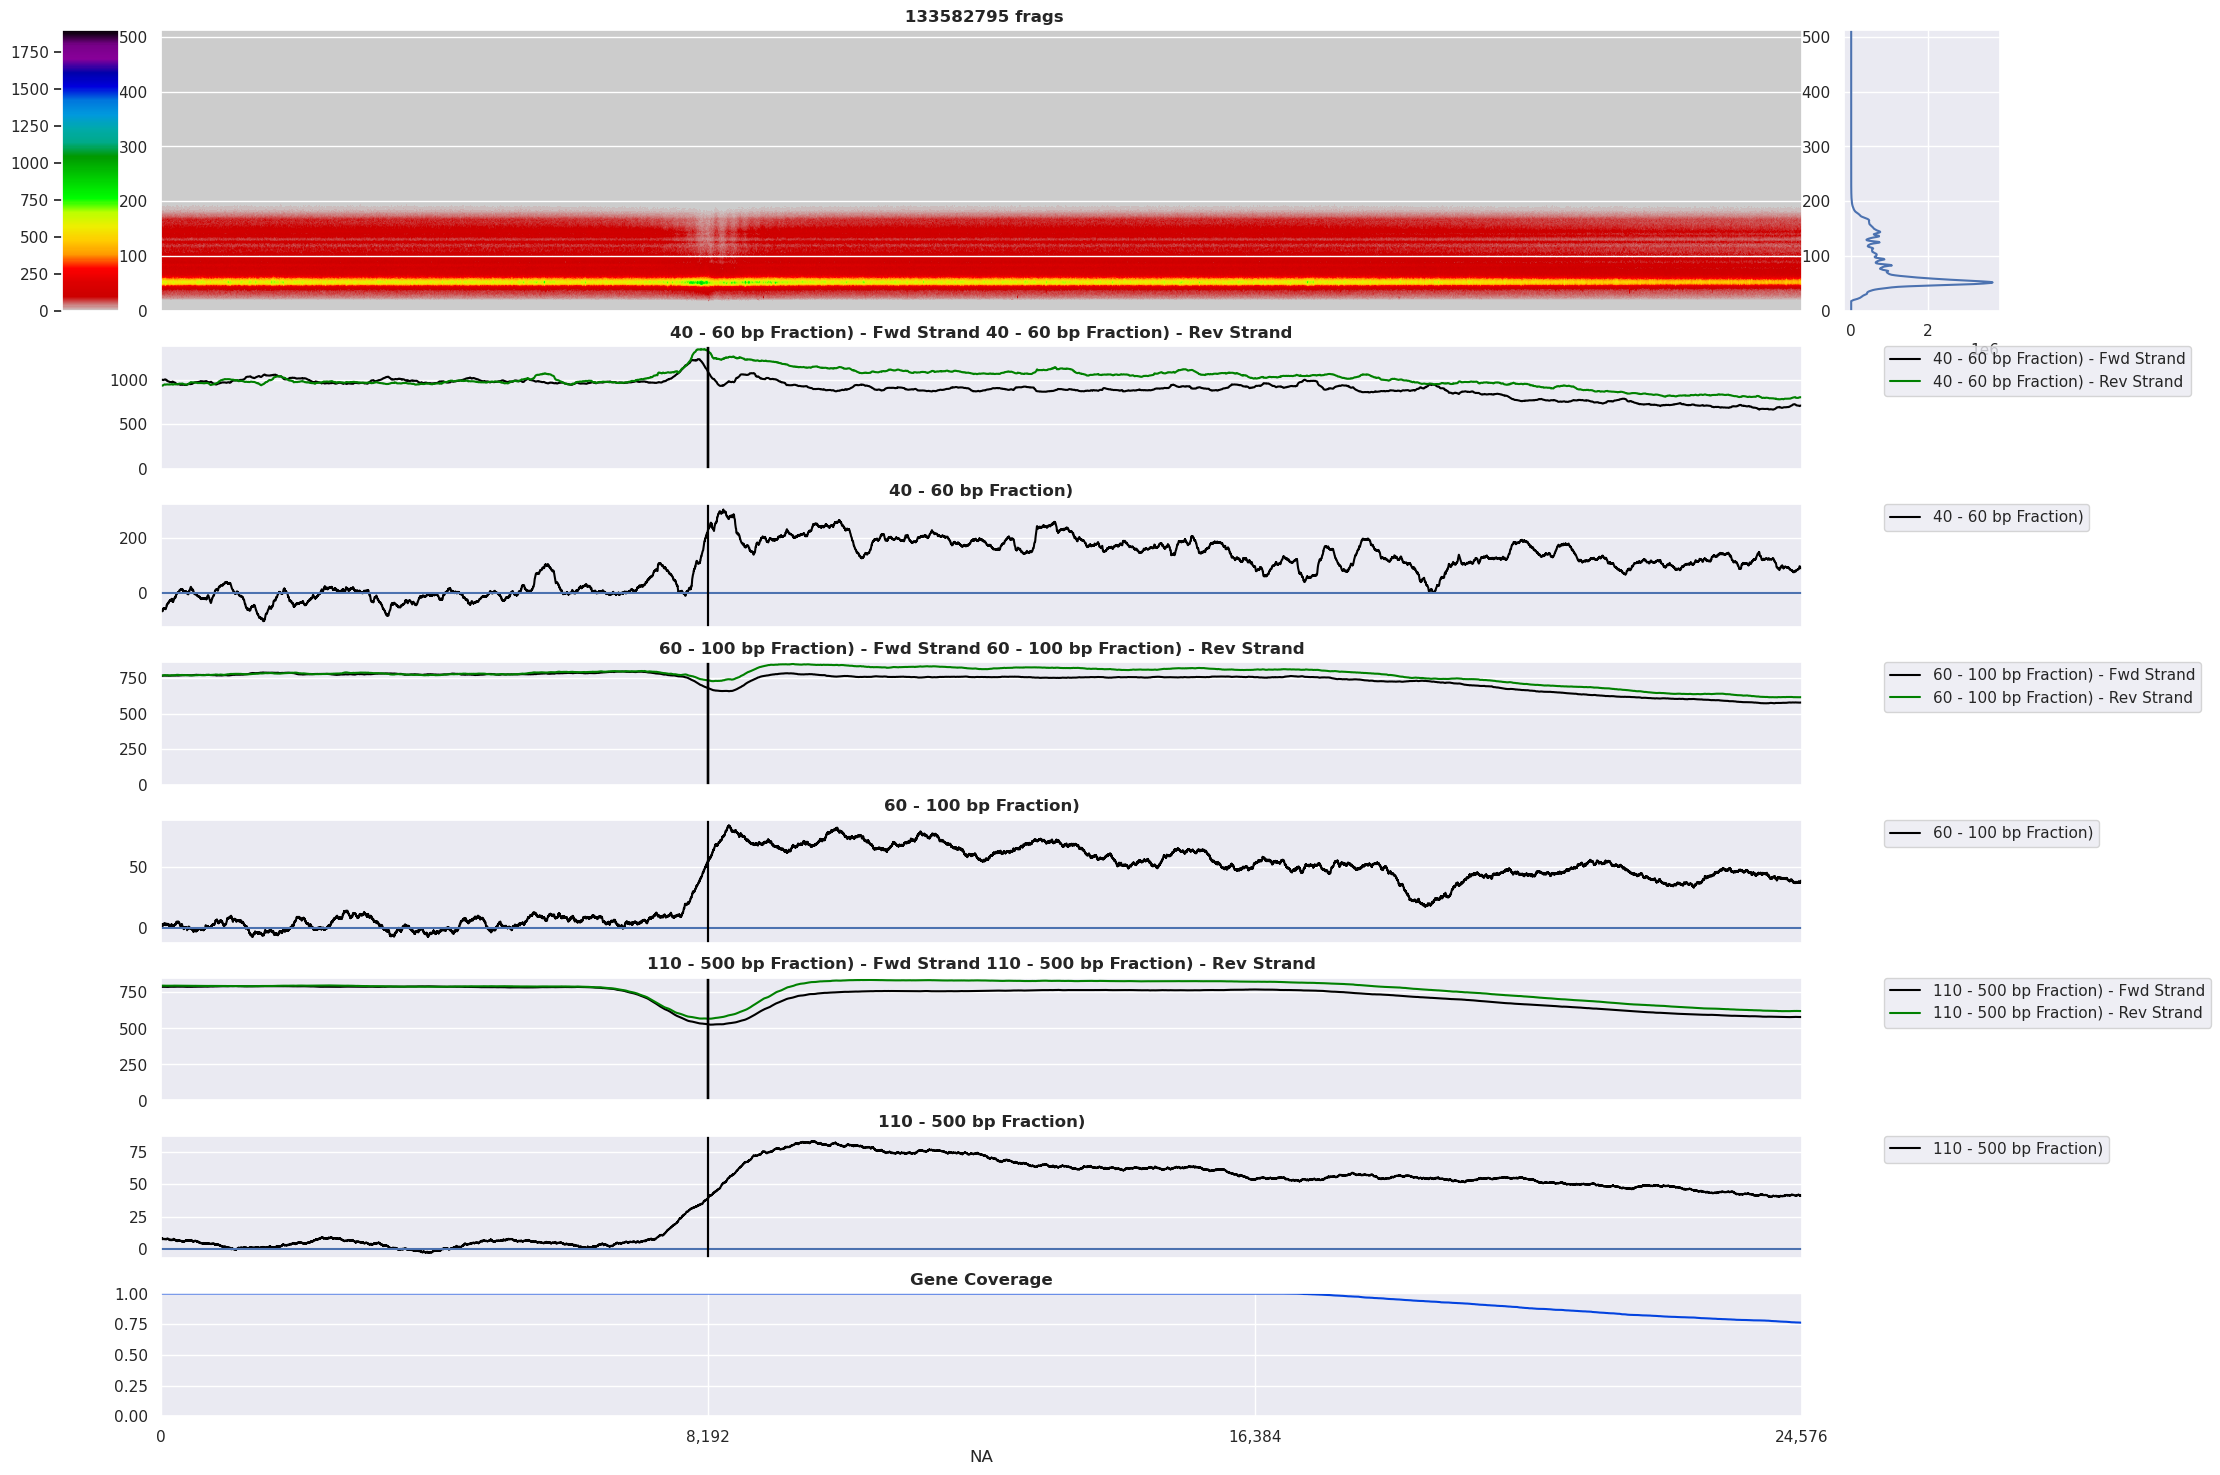

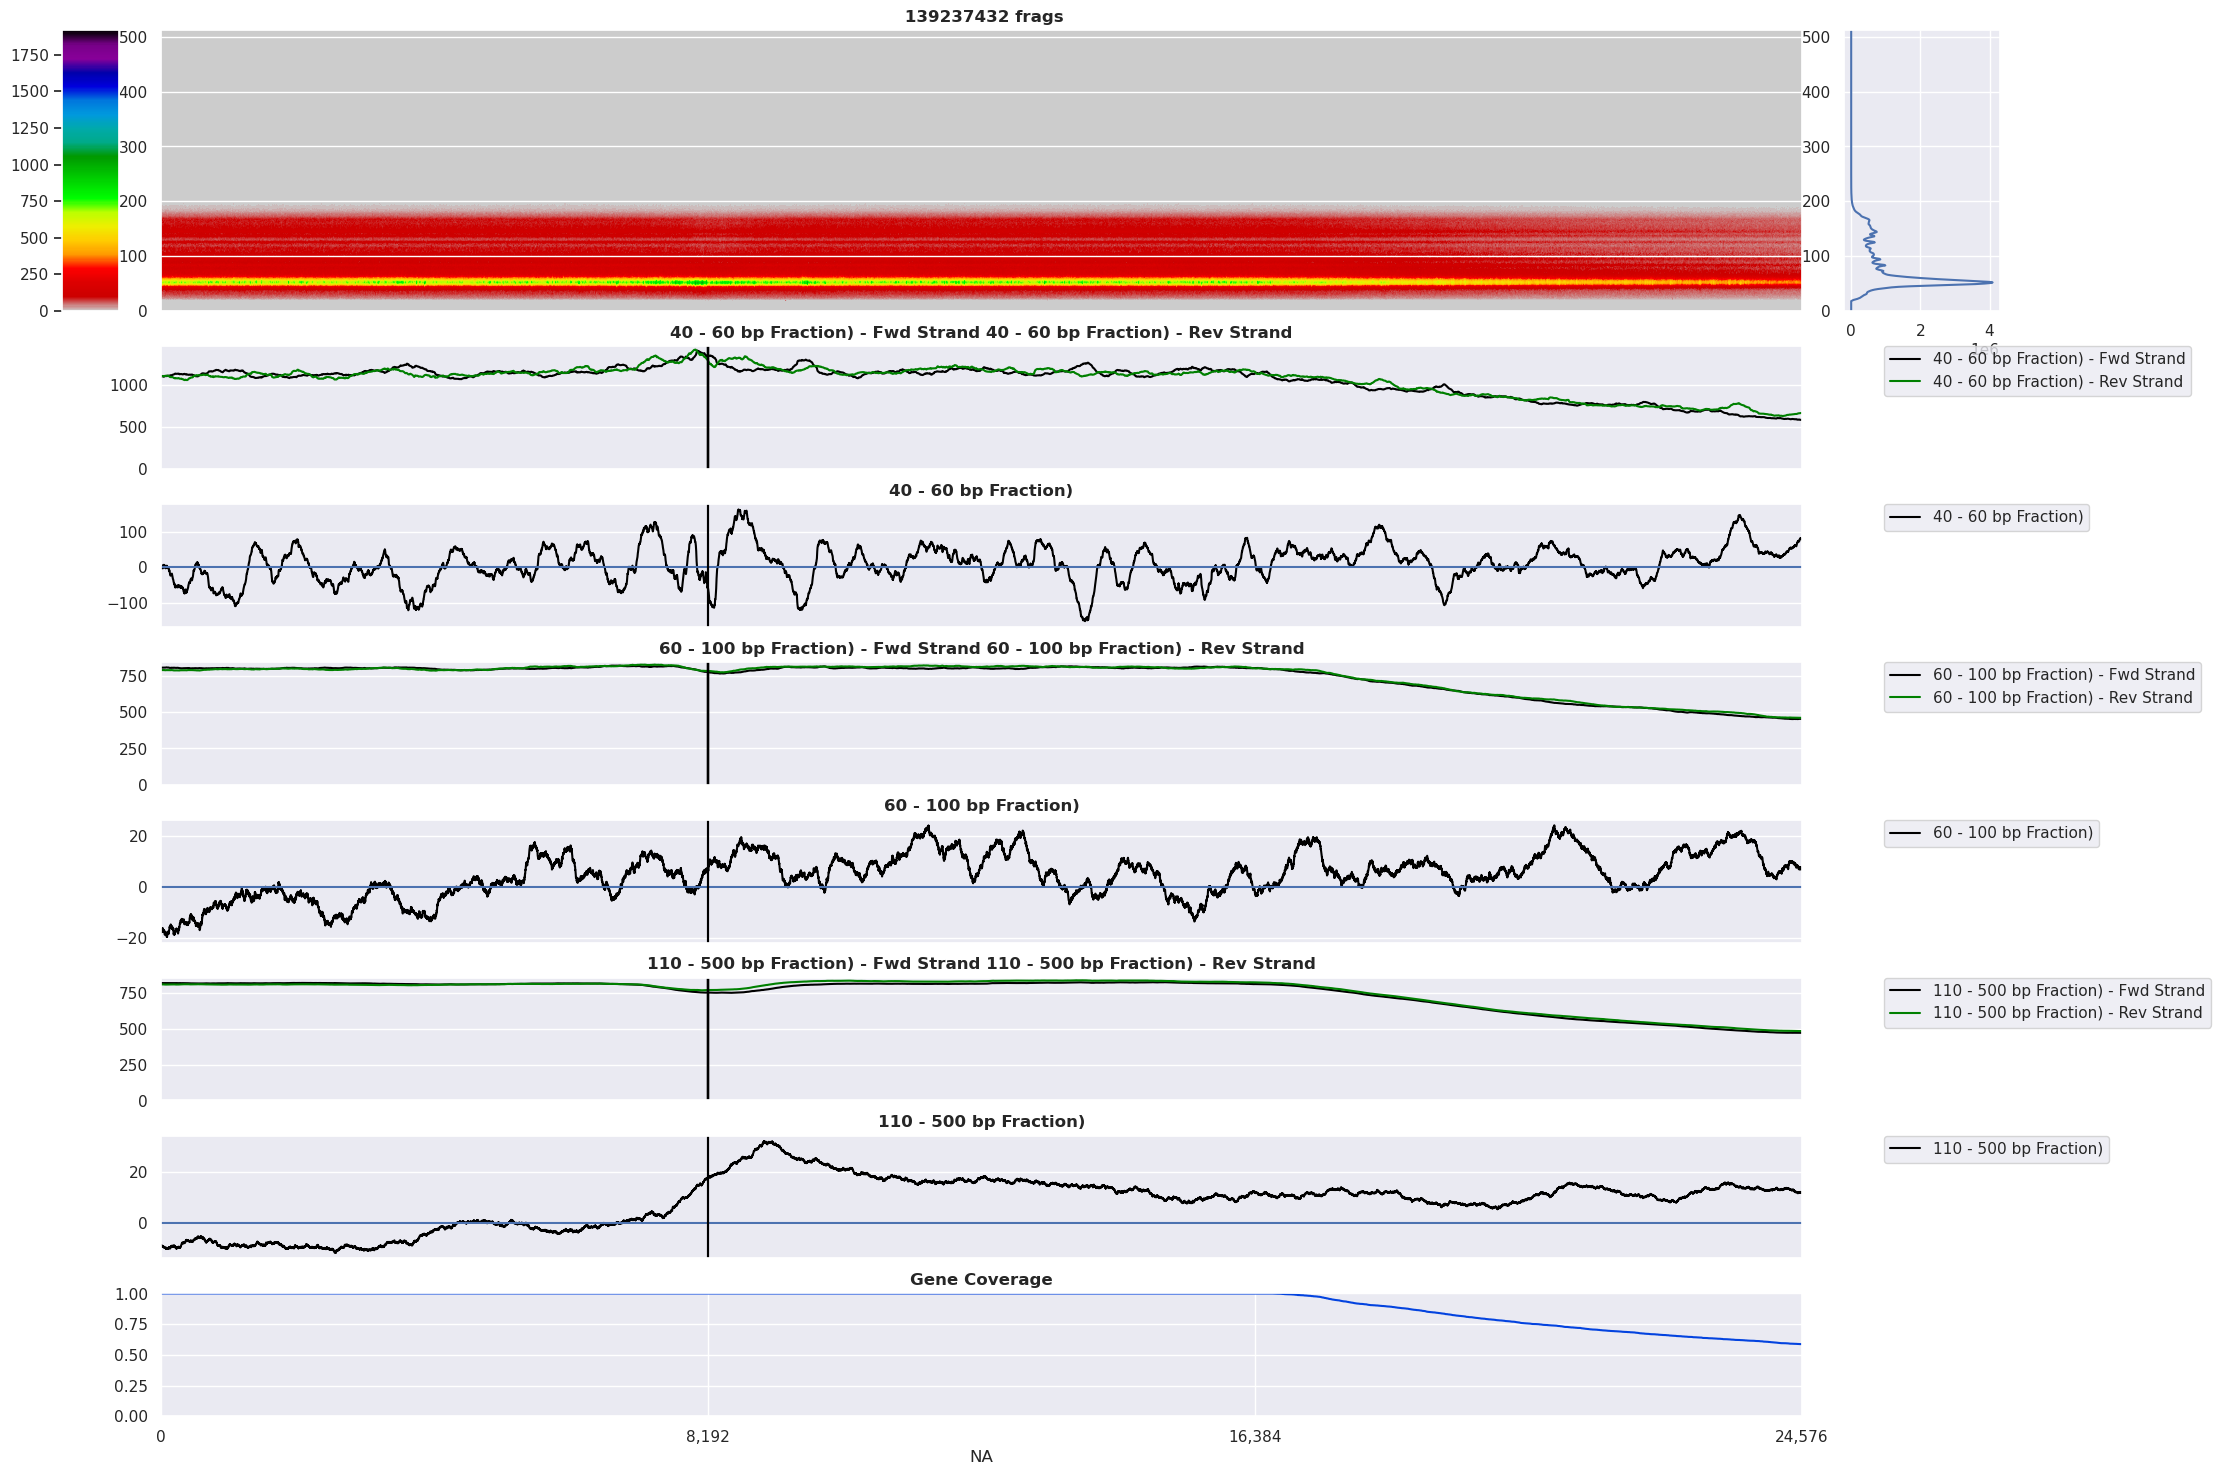

In [27]:
%%time
make_on_off_plots(expression_rdf.rename(columns={'blood_expression': 'expression'}), 'tss')

CPU times: user 4min 27s, sys: 36.6 s, total: 5min 4s
Wall time: 5min 4s


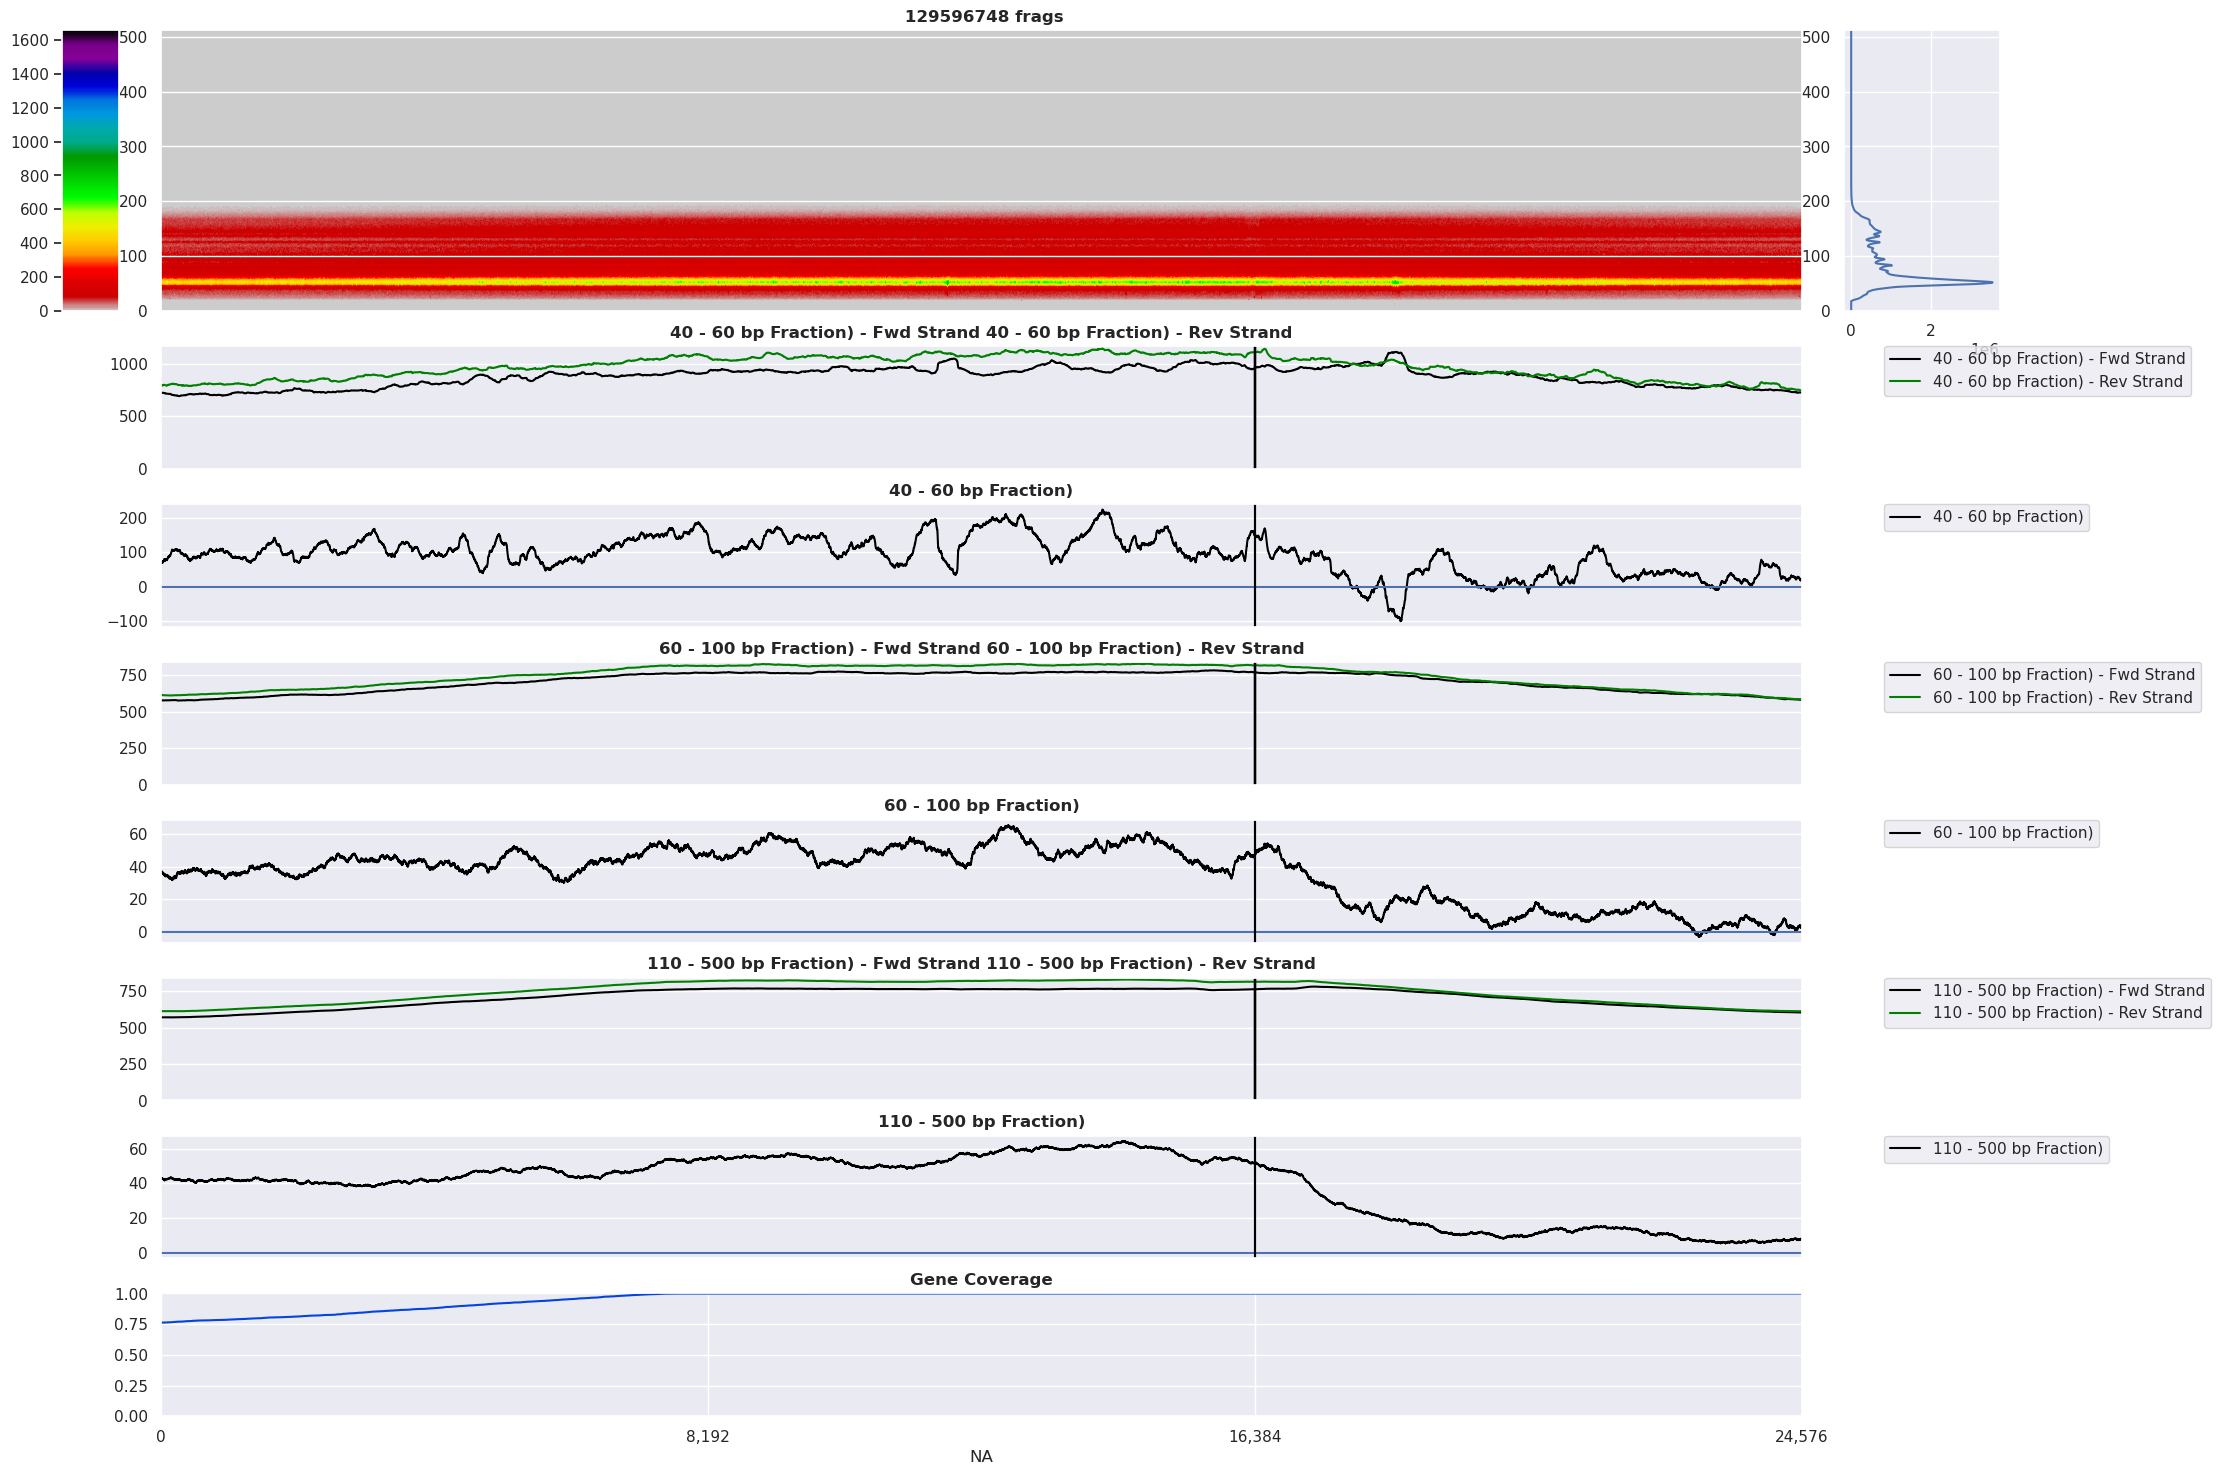

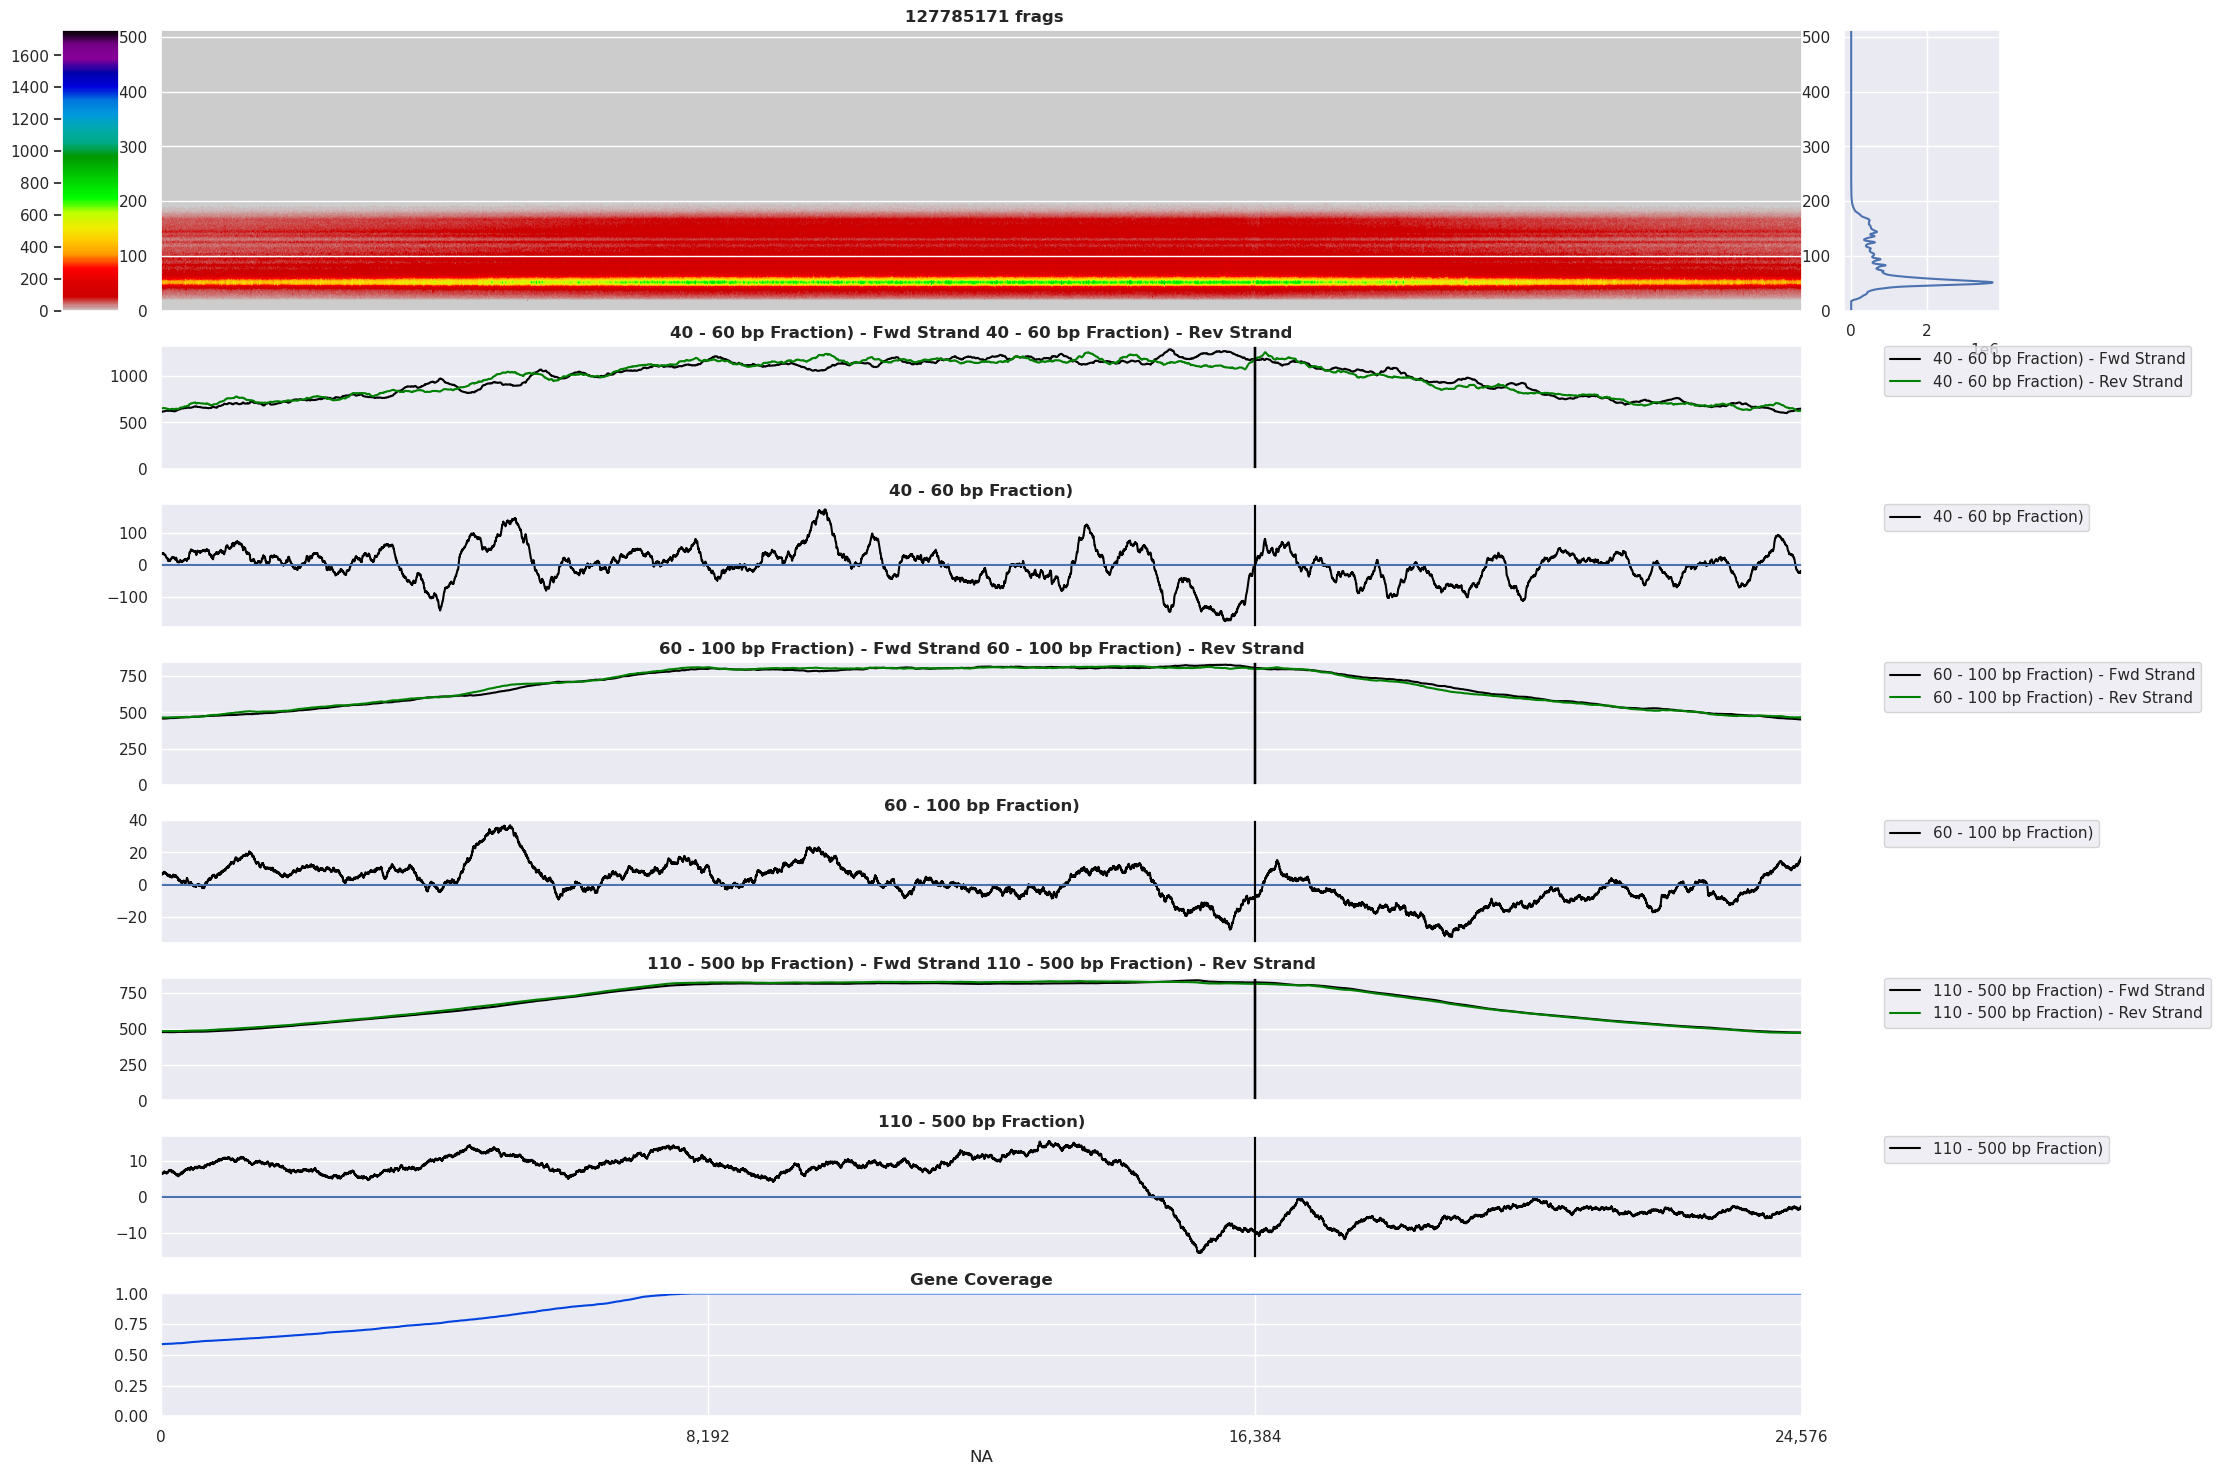

In [28]:
%%time
make_on_off_plots(expression_rdf.rename(columns={'blood_expression': 'expression'}), 'polya')

# Full Gene Scoring

In [29]:
expression_rdf.query("gi_expression < 0.1")

,gene_id,gene_name,contig,strand,start,stop,blood_expression,gi_expression,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fa,n_fragments
0,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.0,0.0,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=300, region=chr1:+...",300
1,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.0,0.0,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=193, region=chr1:+...",193
2,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.0,0.0,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=140, region=chr1:+...",140
3,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.0,0.0,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=373, region=chr1:+...",373
4,ENSG00000186092,OR4F5,chr1,+,57227,79777,0.0,0.0,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=125, region=chr1:+...",125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311809,ENSG00000277150,F8A3,chrX,-,155448722,155466812,0.0,0.0,RD-56162,3,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Moderate,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=260, region=chrX:-...",260
311810,ENSG00000277150,F8A3,chrX,-,155448722,155466812,0.0,0.0,RD-56161,3,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Moderate,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=427, region=chrX:-...",427
311811,ENSG00000277150,F8A3,chrX,-,155448722,155466812,0.0,0.0,RD-56171,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=163, region=chrX:-...",163
311812,ENSG00000277150,F8A3,chrX,-,155448722,155466812,0.0,0.0,RD-56172,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 4,Site_13,"RegionFragmentArray(n_frags=584, region=chrX:-...",584


In [91]:
new_tpm_ranges = [(0, 0.1), (0.1, 1)] + list(zip(range(1, 100, 5), range(5, 101, 5))) # , (1, 5), (5, 10), (10, 20), (20, 70), (70, 500)]
new_tpm_ranges = [(0, 0.1), (0.1, 1), (1, 5), (5, 10), (10, 20), (20, 70), (70, 500)]
new_tpm_ranges = [(0, 0.1), (0.1, 1), (1, 5), (5, 20), (20, 500)]
new_tpm_ranges = [(0, 0.1), (5, 20), (20, 50)]

def boxplot(df):
    df = df.copy()
    for column, prefix in {x: x.split('_')[0] for x in df.columns if x.endswith('_expression')}.items():
        df['tpm_bucket_' + prefix] = None
        for i, (start, stop) in enumerate(new_tpm_ranges):
            df.loc[(start <= df[column]) & (df[column] < stop), 'tpm_bucket_' + prefix] = f"{str(i+1).zfill(2)}: TPM {str(start).zfill(1)}-{str(stop).zfill(1)}"
    return df

In [171]:
def score_fa(record, low_fl=20, high_fl=500):
    fa = record.fa.truncate(left_amt=4096*2, right_amt=4096*2).drop_duplicate_fragments()
    fa = fa.subset_fragment_lengths(low_fl, high_fl)
    strands, counts = np.unique(fa.fragment_strands, return_counts=True)
    if len(strands) != 2:
        if '+' not in strands:
            strands = np.append(strands, '+')
            counts = np.append(counts, 0)
        if '-' not in strands:
            strands = np.append(strands, '-')
            counts = np.append(counts, 0)
    if fa.strand == '+':
        fwd_mask = (strands == '+')
    elif fa.strand == '-':
        fwd_mask = (strands == '-')
    else:
        assert False, f"UNREACHABLE: ({fa.strand})"

    if counts.sum() < 10:
        return None

    return float((counts[~fwd_mask] - counts[fwd_mask])/counts.sum())


In [179]:
from tqdm import tqdm
tqdm.pandas()

# df = boxplot(expression_rdf)
_df = df
full_gene_scores = _df.progress_apply(lambda x: score_fa(x), axis=1).rename('full_gene_score')
fifty_bp_peak_scores = _df.progress_apply(lambda x: score_fa(x, 40, 60), axis=1).rename('fifty_bp_peak_score')
nucleosome_scores = _df.progress_apply(lambda x: score_fa(x, 120, 200), axis=1).rename('nucleosome_score')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311886/311886 [09:55<00:00, 523.87it/s]


In [180]:
scores = pd.concat([pd.DataFrame(df), fifty_bp_peak_scores, nucleosome_scores, full_gene_scores], axis=1).dropna()

In [181]:
# scores = boxplot(scores)

In [265]:
scores[['full_gene_score', 'fifty_bp_peak_score', 'nucleosome_score']].corr('spearman')

,full_gene_score,fifty_bp_peak_score,nucleosome_score
full_gene_score,1.000000,0.775944,0.522007
fifty_bp_peak_score,0.775944,1.000000,0.187830
nucleosome_score,0.522007,0.187830,1.000000


In [183]:
from matplotlib.pyplot import subplots

def make_plots(df):
    fig, axar = subplots(3, 1, sharex=True, sharey=True)
    df.groupby(['label', 'tpm_bucket_blood']).score.agg(['mean']).plot.bar(ax=axar[0])
    df.query("gi_expression < .1").groupby(['label', 'tpm_bucket_blood']).score.agg(['mean']).plot.bar(ax=axar[1])
    df.query("blood_expression < .1").groupby(['label', 'tpm_bucket_gi']).score.agg(['mean']).plot.bar(ax=axar[2])
    
def print_score(sample_pair):
    _df_healthy = scores.query("sample_id == @sample_pair[0]")[['gene_id', 'gi_expression', 'blood_expression', 'score']].rename(columns={'score': 'healthy_score'}).set_index('gene_id')
    _df = _df_healthy.join(scores.query("sample_id == @sample_pair[1]")[['gene_id', 'score']].rename(columns={'score': 'disease_score'}).set_index('gene_id'))
    _disease_df = _df.query("gi_expression > 10 and blood_expression < 0.01")
    _healthy_df = _df.query("gi_expression < 0.1 and blood_expression > 10")
    _on_df = _df.query("gi_expression > 10 and blood_expression > 10").sample(500)
    _off_df = _df.query("gi_expression < 0.1 and blood_expression < 0.1").sample(500)
    rv = pd.DataFrame(dict(
        disease=(_disease_df.disease_score > _disease_df.healthy_score).value_counts(), 
        healthy=(_healthy_df.disease_score > _healthy_df.healthy_score).value_counts(),
        on=(_on_df.disease_score > _on_df.healthy_score).value_counts(),
        off=(_off_df.disease_score > _off_df.healthy_score).value_counts(),
    )).rename(index={False: 'pred_healthy', True: 'pred_disease'}).sort_index()
    rv = rv/rv.sum(axis=0)
    cf = rv[['on', 'off']].mean(axis=1)
    return rv[['disease', 'healthy']] - np.vstack([cf, cf]).T


In [201]:
def plot_simulate(df, blood_or_gi):
    res = []
    for i in range(100):
        res.append(df.groupby(['label', f'tpm_bucket_{blood_or_gi}']).sample(100, replace=False).groupby(['label', f'tpm_bucket_{blood_or_gi}']).nucleosome_score.mean()) # agg(['count', 'mean', 'std'])
    pd.concat(res).reset_index().sort_values(f'tpm_bucket_{blood_or_gi}').boxplot('nucleosome_score', by=[f'tpm_bucket_{blood_or_gi}', 'label'], rot=90)

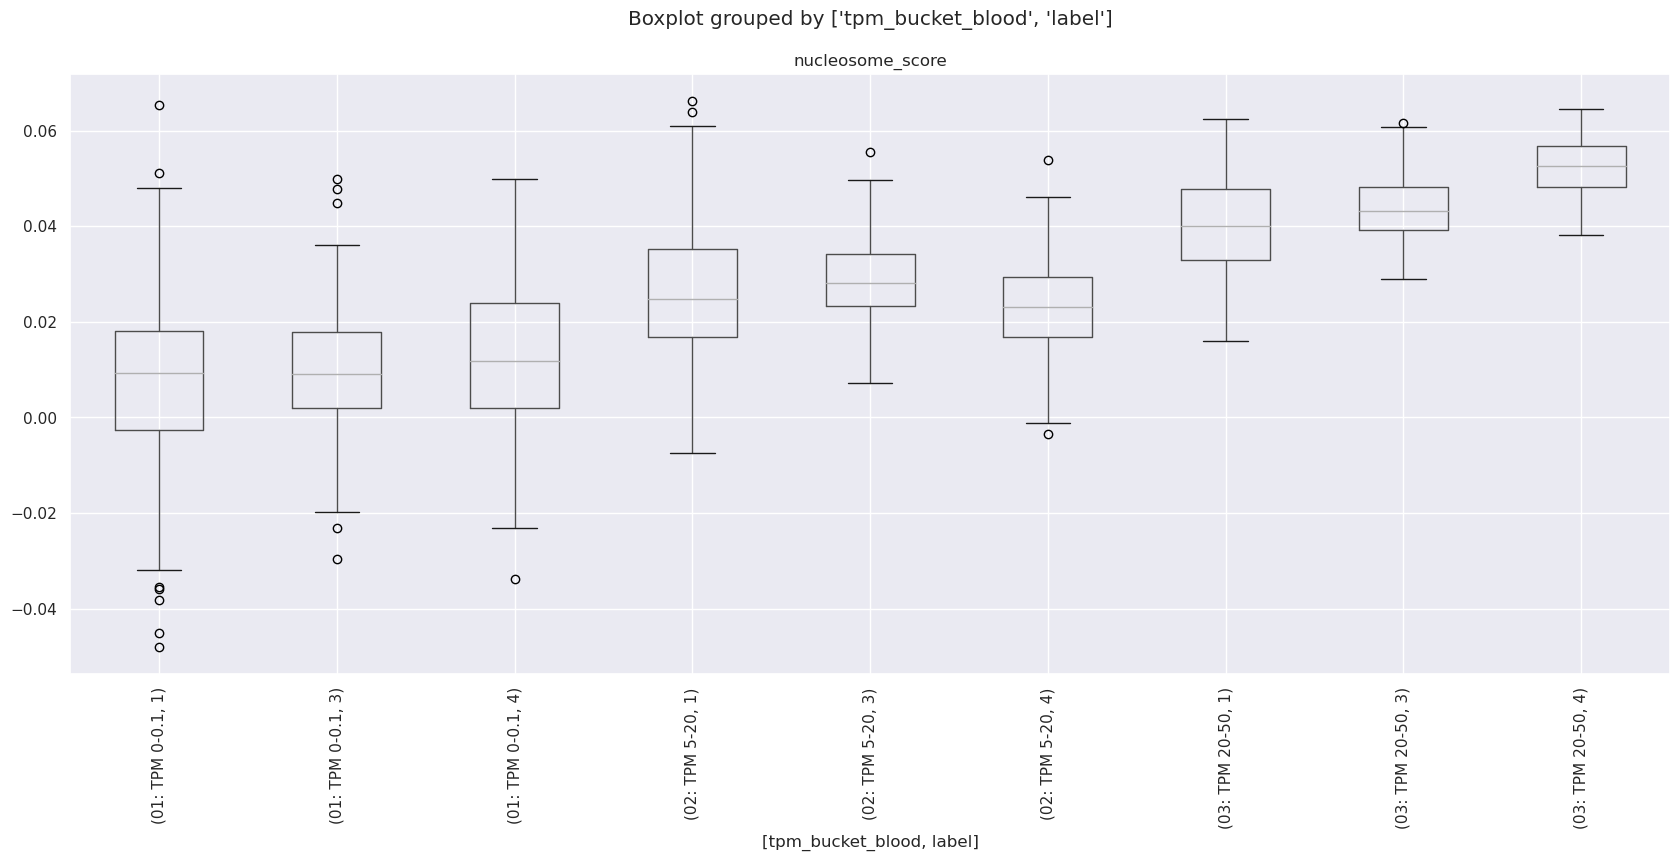

In [202]:
plot_simulate(scores.query("(label == 1 or label == 3 or label == 4) and gi_expression < .1"), 'blood')

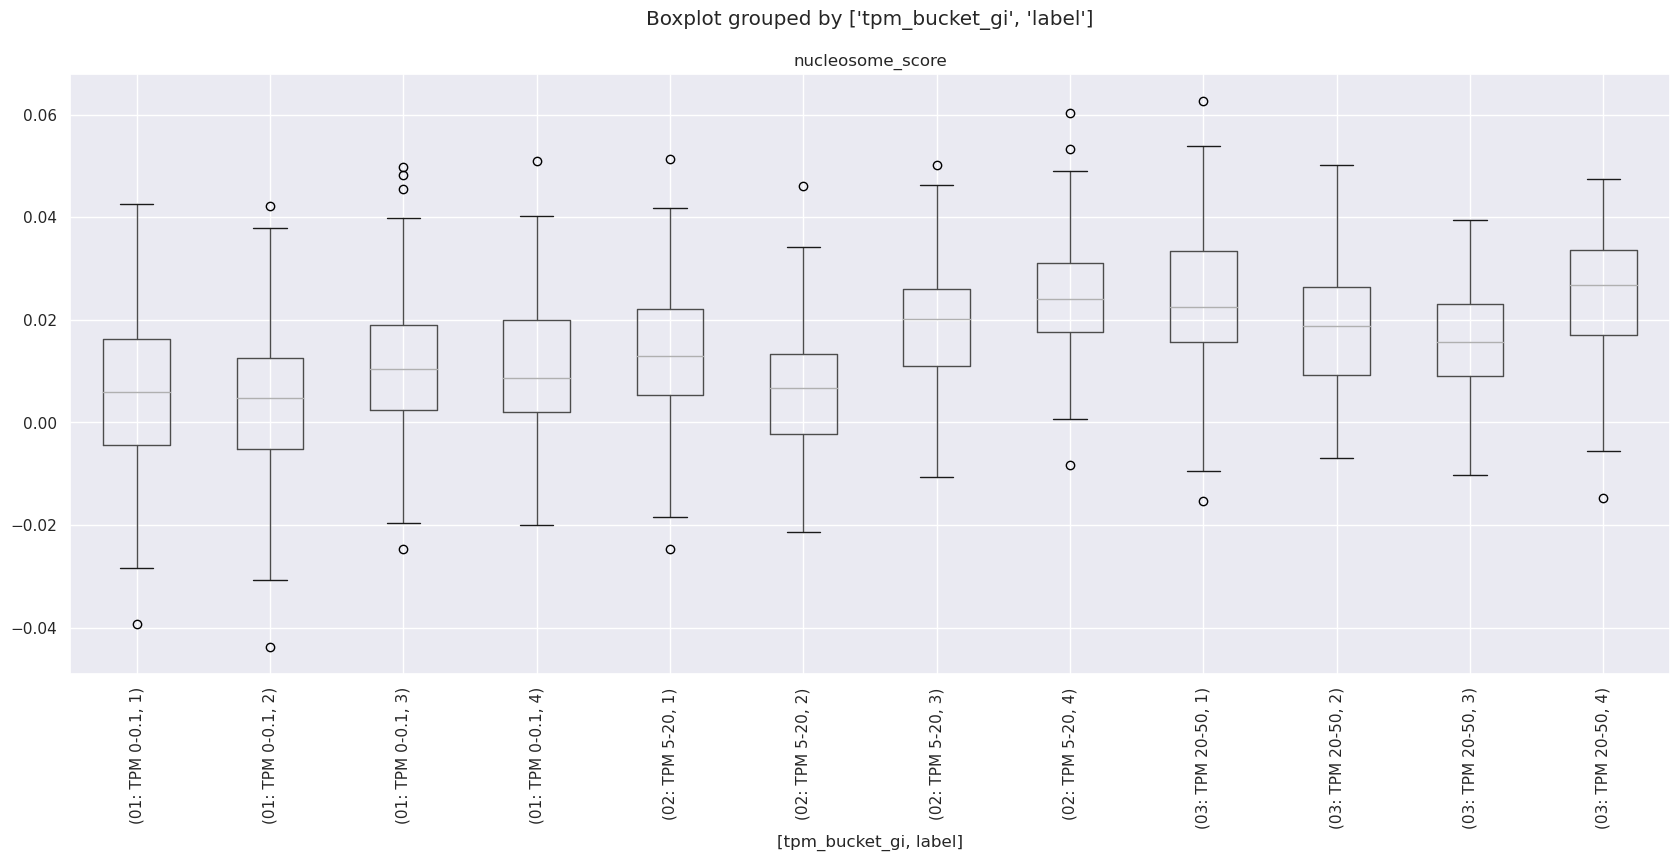

In [267]:
plot_simulate(scores.query("(label == 1 or label == 3 or label == 4 or True) and blood_expression < .1"), 'gi')

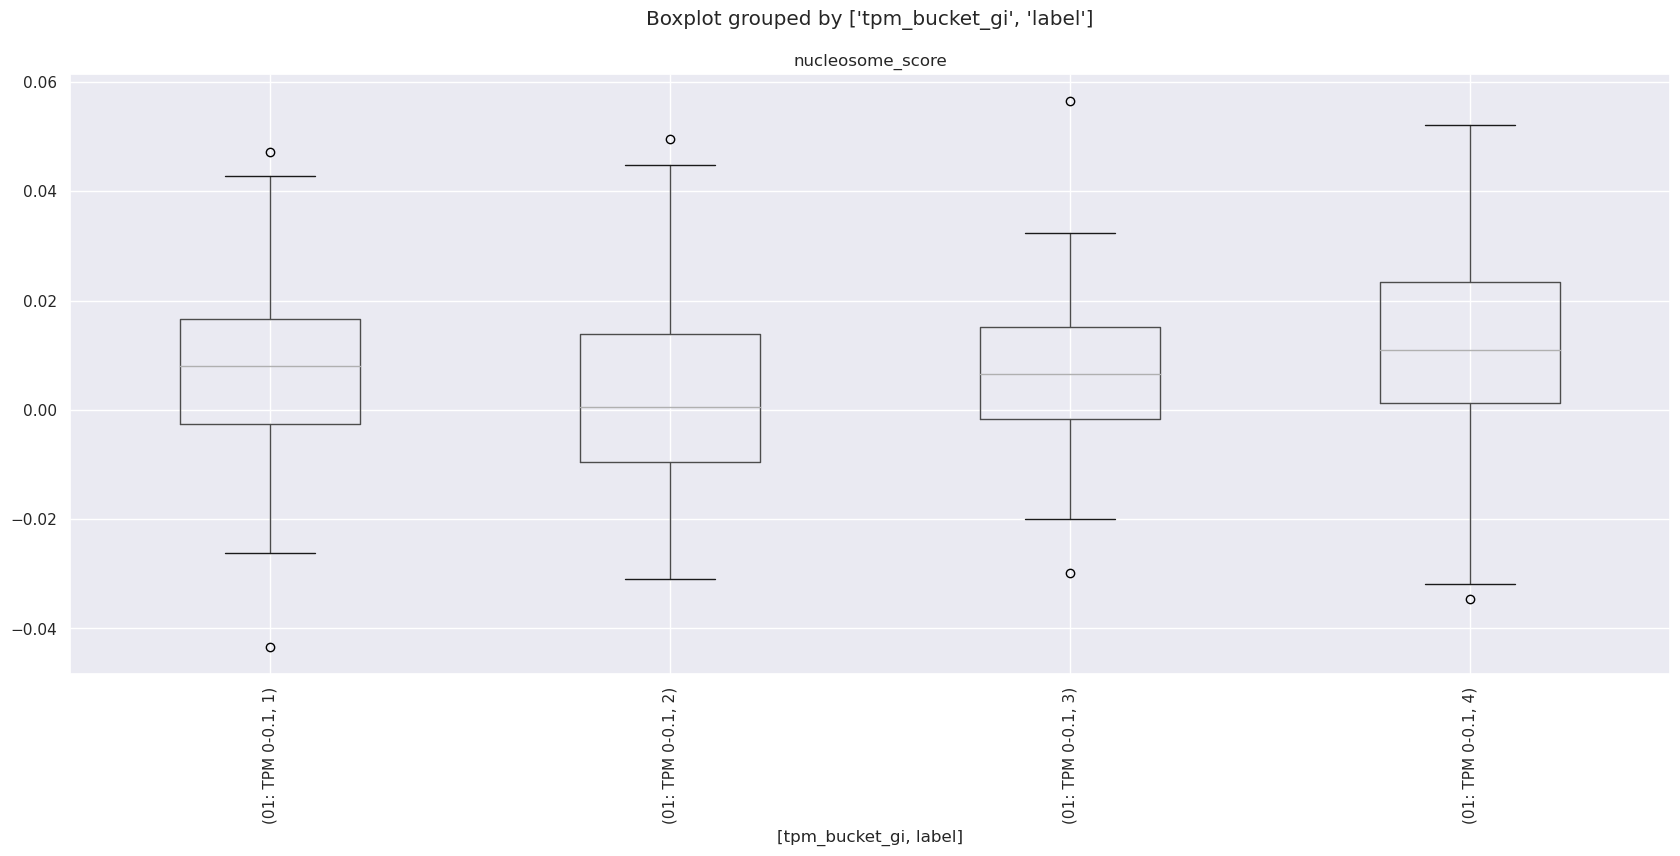

In [268]:
plot_simulate(scores.query("blood_expression < 1 and gi_expression < 1"), 'gi')

# Region Selection

In [208]:
scores

,gene_id,gene_name,contig,strand,start,stop,blood_expression,gi_expression,sample_id,label,...,ENDO_CATEGORY,Cluster,SITE_NUMBER,fa,n_fragments,tpm_bucket_blood,tpm_bucket_gi,fifty_bp_peak_score,nucleosome_score,full_gene_score
162,ENSG00000131591,C1orf159,chr1,-,1073626,1099757,6.332242,7.189,RD-56170,1,...,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=2491, region=chr1:...",2491,02: TPM 5-20,02: TPM 5-20,0.228346,0.116279,0.208955
163,ENSG00000131591,C1orf159,chr1,-,1073626,1099757,6.332242,7.189,RD-56169,1,...,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=3537, region=chr1:...",3537,02: TPM 5-20,02: TPM 5-20,0.317919,-0.164179,0.198830
164,ENSG00000131591,C1orf159,chr1,-,1073626,1099757,6.332242,7.189,RD-56168,1,...,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=1494, region=chr1:...",1494,02: TPM 5-20,02: TPM 5-20,0.245283,0.116279,0.144828
165,ENSG00000131591,C1orf159,chr1,-,1073626,1099757,6.332242,7.189,RD-56167,1,...,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=2955, region=chr1:...",2955,02: TPM 5-20,02: TPM 5-20,0.153153,0.159091,0.183391
166,ENSG00000131591,C1orf159,chr1,-,1073626,1099757,6.332242,7.189,RD-56165,1,...,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=1376, region=chr1:...",1376,02: TPM 5-20,02: TPM 5-20,0.287671,0.217391,0.266667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311863,ENSG00000124333,VAMP7,chrX,+,155873153,155951961,43.414360,23.092,RD-56162,3,...,Moderate,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=4307, region=chrX:...",4307,03: TPM 20-50,03: TPM 20-50,0.094891,0.115607,0.070640
311864,ENSG00000124333,VAMP7,chrX,+,155873153,155951961,43.414360,23.092,RD-56161,3,...,Moderate,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=6677, region=chrX:...",6677,03: TPM 20-50,03: TPM 20-50,0.206767,0.142857,0.139854
311865,ENSG00000124333,VAMP7,chrX,+,155873153,155951961,43.414360,23.092,RD-56171,4,...,Severe,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=3344, region=chrX:...",3344,03: TPM 20-50,03: TPM 20-50,-0.009346,0.119565,0.034965
311866,ENSG00000124333,VAMP7,chrX,+,155873153,155951961,43.414360,23.092,RD-56172,4,...,Severe,Patient Group 4,Site_13,"RegionFragmentArray(n_frags=8497, region=chrX:...",8497,03: TPM 20-50,03: TPM 20-50,0.100000,0.060998,0.058640


In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import random

In [210]:
from sklearn.model_selection import cross_val_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

clf_df = scores.set_index(keys='gene_name').query("gi_expression > 10 and blood_expression < 0.1")[['label', 'full_gene_score']].dropna()
clf = RandomForestClassifier()
clf = clf.fit(clf_df[['full_gene_score']], clf_df.label)
cross_val_score(clf, clf_df[['full_gene_score']], clf_df.label, cv=10)

array([0.29974811, 0.26448363, 0.24685139, 0.29974811, 0.24685139, 0.23929471, 0.25252525, 0.21464646, 0.25      , 0.28282828])

# CRC Gene Expression

In [212]:
scores.groupby(['gene_id', 'label']).nucleosome_score.mean().reset_index(level=1).pivot(columns='label')

nucleosome_score                              
label                          1         2         3         4
gene_id                                                       
ENSG00000000457         0.063845  0.017590  0.077737  0.116682
ENSG00000000971         0.051549 -0.011422  0.006400 -0.007502
ENSG00000001036         0.015313  0.002557  0.062327  0.160717
ENSG00000001084         0.018229  0.041845  0.033894  0.045682
ENSG00000001167         0.065516  0.013639 -0.001737  0.026689
...                          ...       ...       ...       ...
ENSG00000279486        -0.085802  0.090802 -0.087207  0.087214
ENSG00000280165         0.065188  0.027762  0.191860  0.177288
ENSG00000280204        -0.144292  0.021544 -0.117626 -0.030221
ENSG00000280236         0.200710  0.118329  0.084519 -0.069940
ENSG00000280314         0.101860  0.087790  0.147914  0.052370

[6098 rows x 4 columns]

In [269]:
pt = scores.groupby(['gene_id', 'label']).fifty_bp_peak_score.mean().reset_index(level=1).pivot(columns='label')
pt.columns = pt.columns.get_level_values(1)
(pt[4] - pt[1]).dropna().rename("score_diff")

gene_id
ENSG00000000457   -0.036067
ENSG00000000971    0.048247
ENSG00000001036    0.083822
ENSG00000001084   -0.052503
ENSG00000001167    0.040732
                     ...   
ENSG00000279486   -0.014970
ENSG00000280165   -0.022941
ENSG00000280204    0.099138
ENSG00000280236   -0.260580
ENSG00000280314   -0.013179
Name: score_diff, Length: 5881, dtype: float64

<AxesSubplot:ylabel='Frequency'>

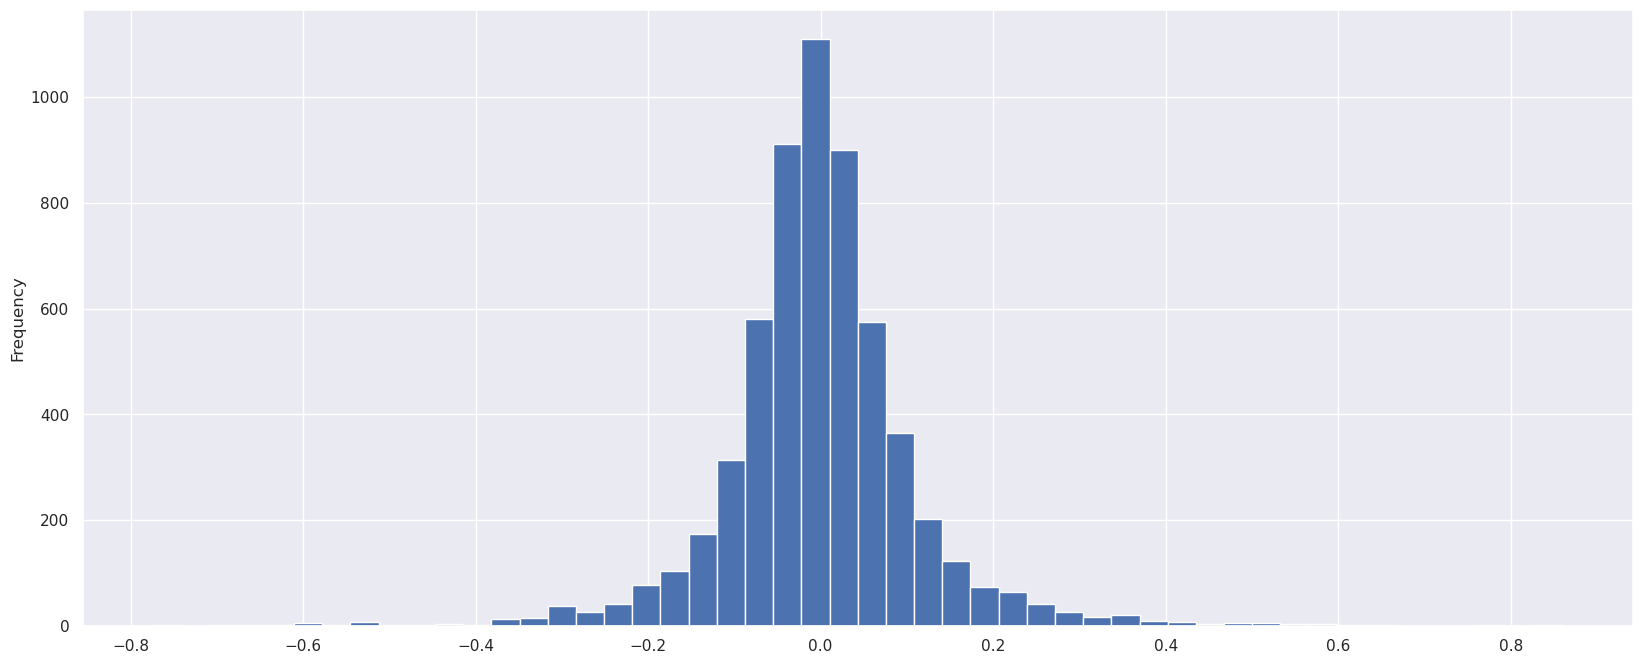

In [287]:
expression_rdf[['gene_id', 'gene_name', 'strand', 'blood_expression', 'gi_expression']].set_index('gene_id').drop_duplicates().join((pt[4] - pt[1]).rename("score_diff")).dropna().score_diff.plot.hist(bins=50)

In [270]:
expression_rdf[['gene_id', 'gene_name', 'strand', 'blood_expression', 'gi_expression']].set_index('gene_id').drop_duplicates().join((pt[4] - pt[1]).rename("score_diff")).sort_values('score_diff').dropna().query("blood_expression < 0.1 and gi_expression > 10").tail(40)

,gene_name,strand,blood_expression,gi_expression,score_diff
gene_id,,,,,
ENSG00000243789,JMJD7,+,0.000000,11.602,0.080600
ENSG00000165238,WNK2,+,0.002500,19.814,0.082688
ENSG00000106588,PSMA2,-,0.010057,26.802,0.082771
ENSG00000148357,HMCN2,+,0.000000,13.771,0.082870
ENSG00000183317,EPHA10,-,0.000000,13.342,0.084144
ENSG00000150527,MIA2,+,0.000000,12.634,0.086206
ENSG00000164107,HAND2,-,0.000000,10.319,0.086494
ENSG00000124205,EDN3,+,0.000000,17.252,0.089719
ENSG00000170689,HOXB9,-,0.000000,44.561,0.093884


In [249]:
def make_tracks_coverage_tracks(_rdf_w_fas, tss_or_polya):
    if tss_or_polya == 'tss':
        resize_method_name = 'right_resize'
    elif tss_or_polya == 'polya':
        resize_method_name = 'left_resize'
    else:
        raise ValueError(f"Unrecognized value for tss_or_polya '{tss_or_polya}'")

    merged_fa = merge_fragment_arrays([getattr(_.reverse_strand_if_negative(), resize_method_name)(1024*24) for _ in _rdf_w_fas.fa.tolist()]) # cell_type == 'all' and 
    tracks = make_single_strand_tss_tracks(merged_fa, include_vplot=True, tss_or_polya=tss_or_polya)
    # tracks.append(VectorTrack(make_gene_cov(merged_fa, tss_or_polya)[(slice(None, merged_fa.length) if tss_or_polya == 'tss' else slice(-merged_fa.length, None))], merged_fa.plot_region, name='Gene Coverage', ylim=(0, 1)))

    return tracks

In [300]:
GENE_NAME = 'HMCN2'

In [301]:
expression_rdf.query("gene_name.str.startswith(@GENE_NAME)") # .gene_name.value_counts()

,gene_id,gene_name,contig,strand,start,stop,blood_expression,gi_expression,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fa,n_fragments
296424,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=11961, region=chr9...",11961
296425,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=14489, region=chr9...",14489
296426,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=7139, region=chr9:...",7139
296427,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=13164, region=chr9...",13164
296428,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=7808, region=chr9:...",7808
296429,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56166,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=6128, region=chr9:...",6128
296430,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56150,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=7076, region=chr9:...",7076
296431,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56153,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=11955, region=chr9...",11955
296432,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56154,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 4,Site_13,"RegionFragmentArray(n_frags=10207, region=chr9...",10207
296433,ENSG00000148357,HMCN2,chr9,+,130257568,130346798,0.0,13.771,RD-56155,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=7825, region=chr9:...",7825


(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 6443 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='chr9'>])

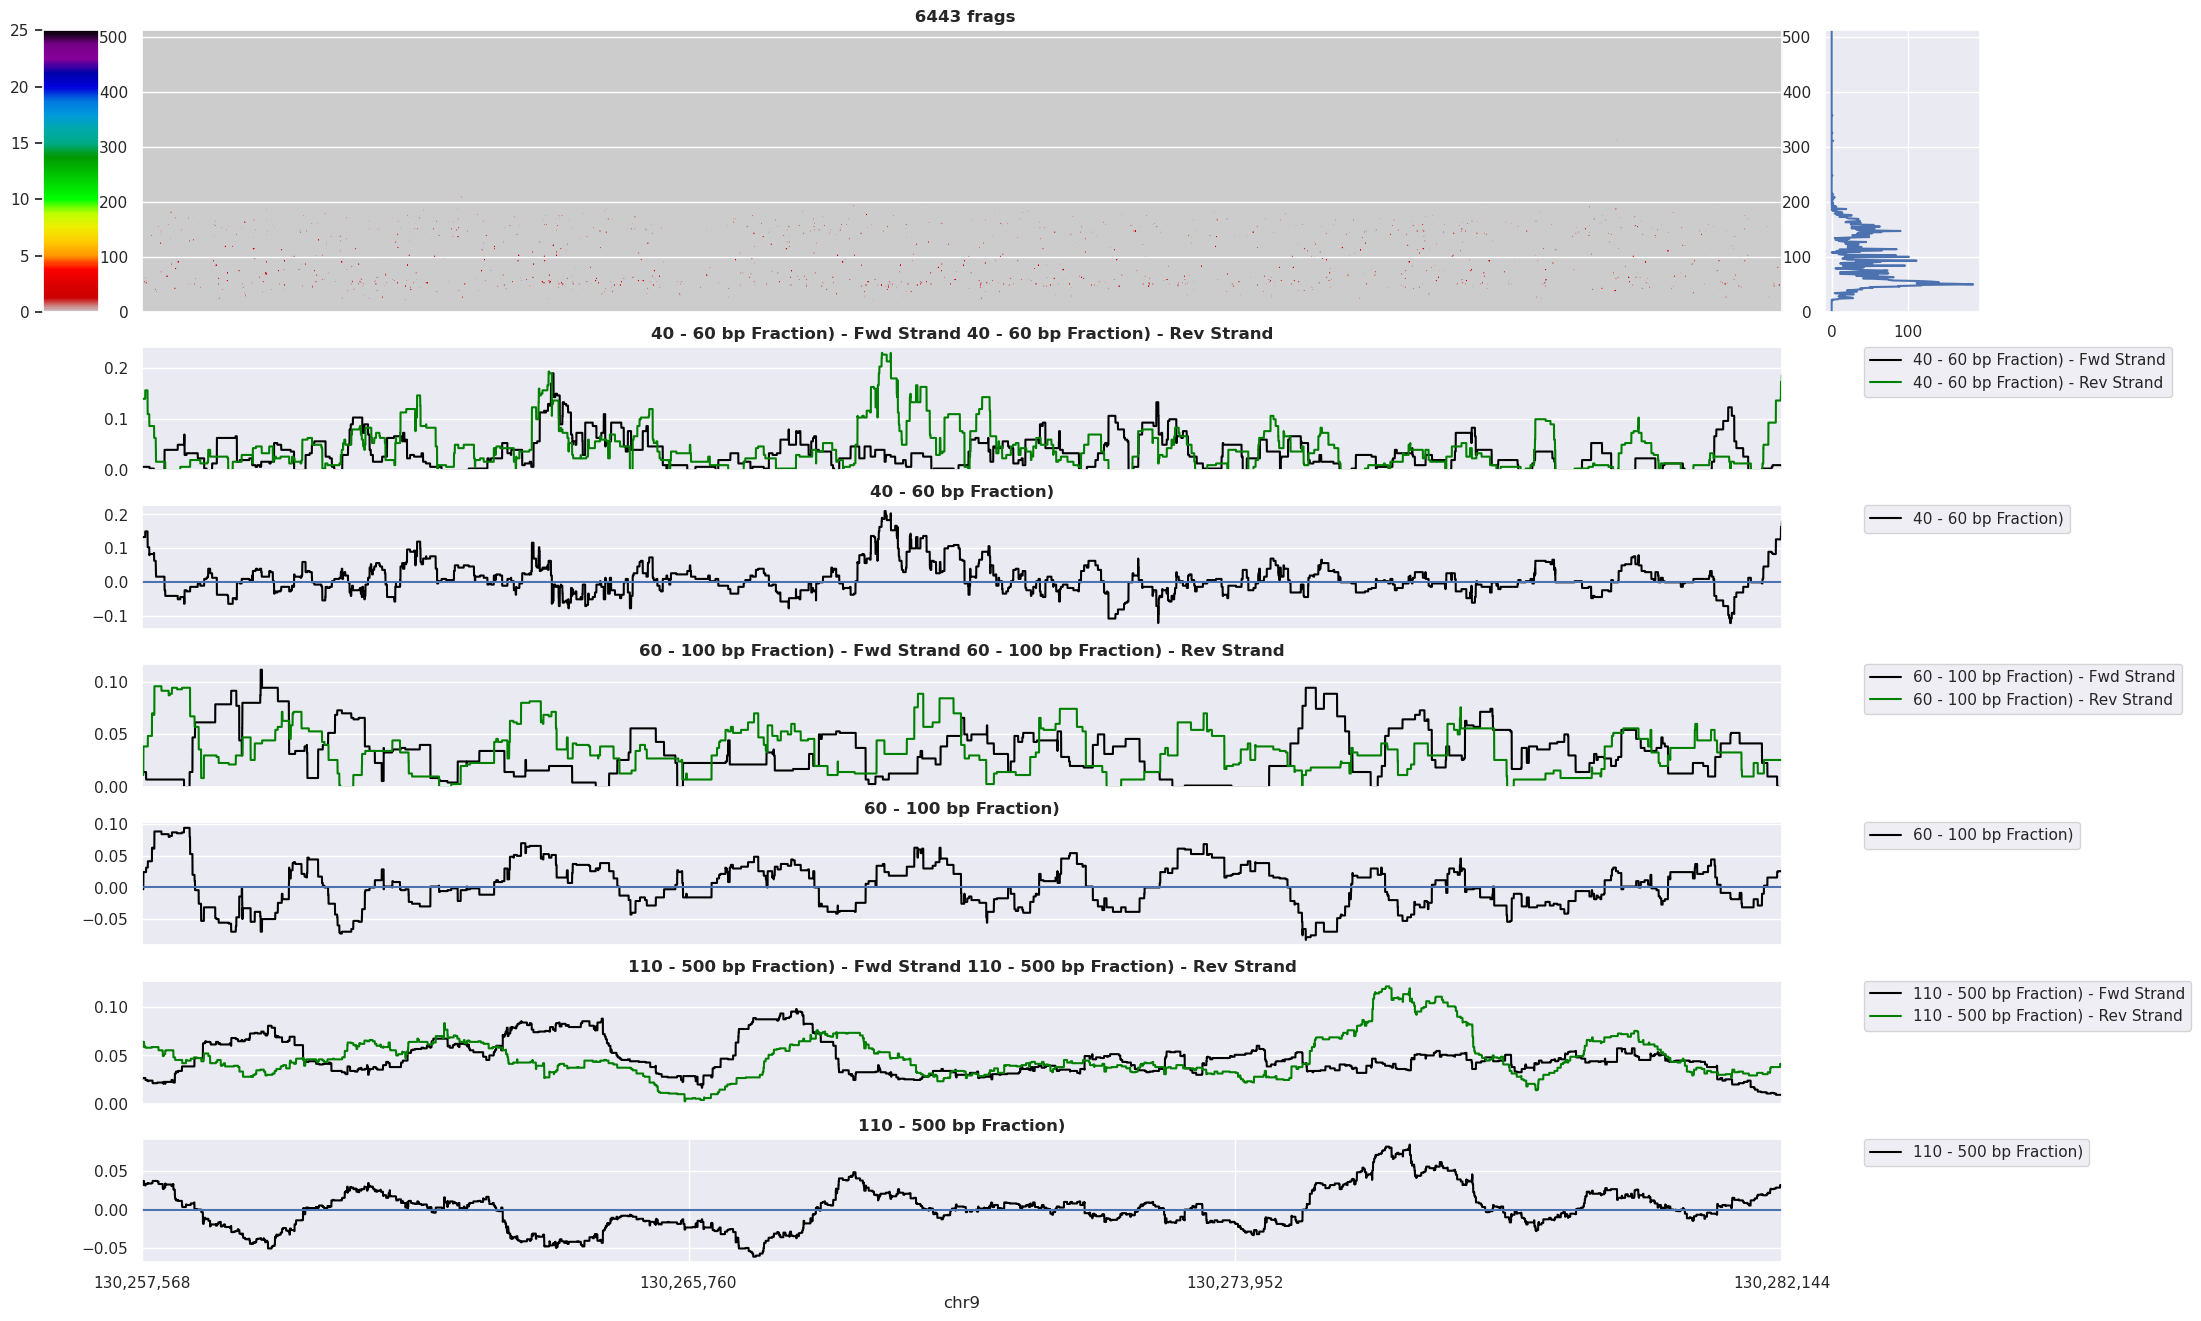

In [302]:
make_tracks_coverage_tracks(expression_rdf.query("gene_name.str.startswith(@GENE_NAME) and label == 4"), 'tss').plot()

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 12772 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='chr9'>])

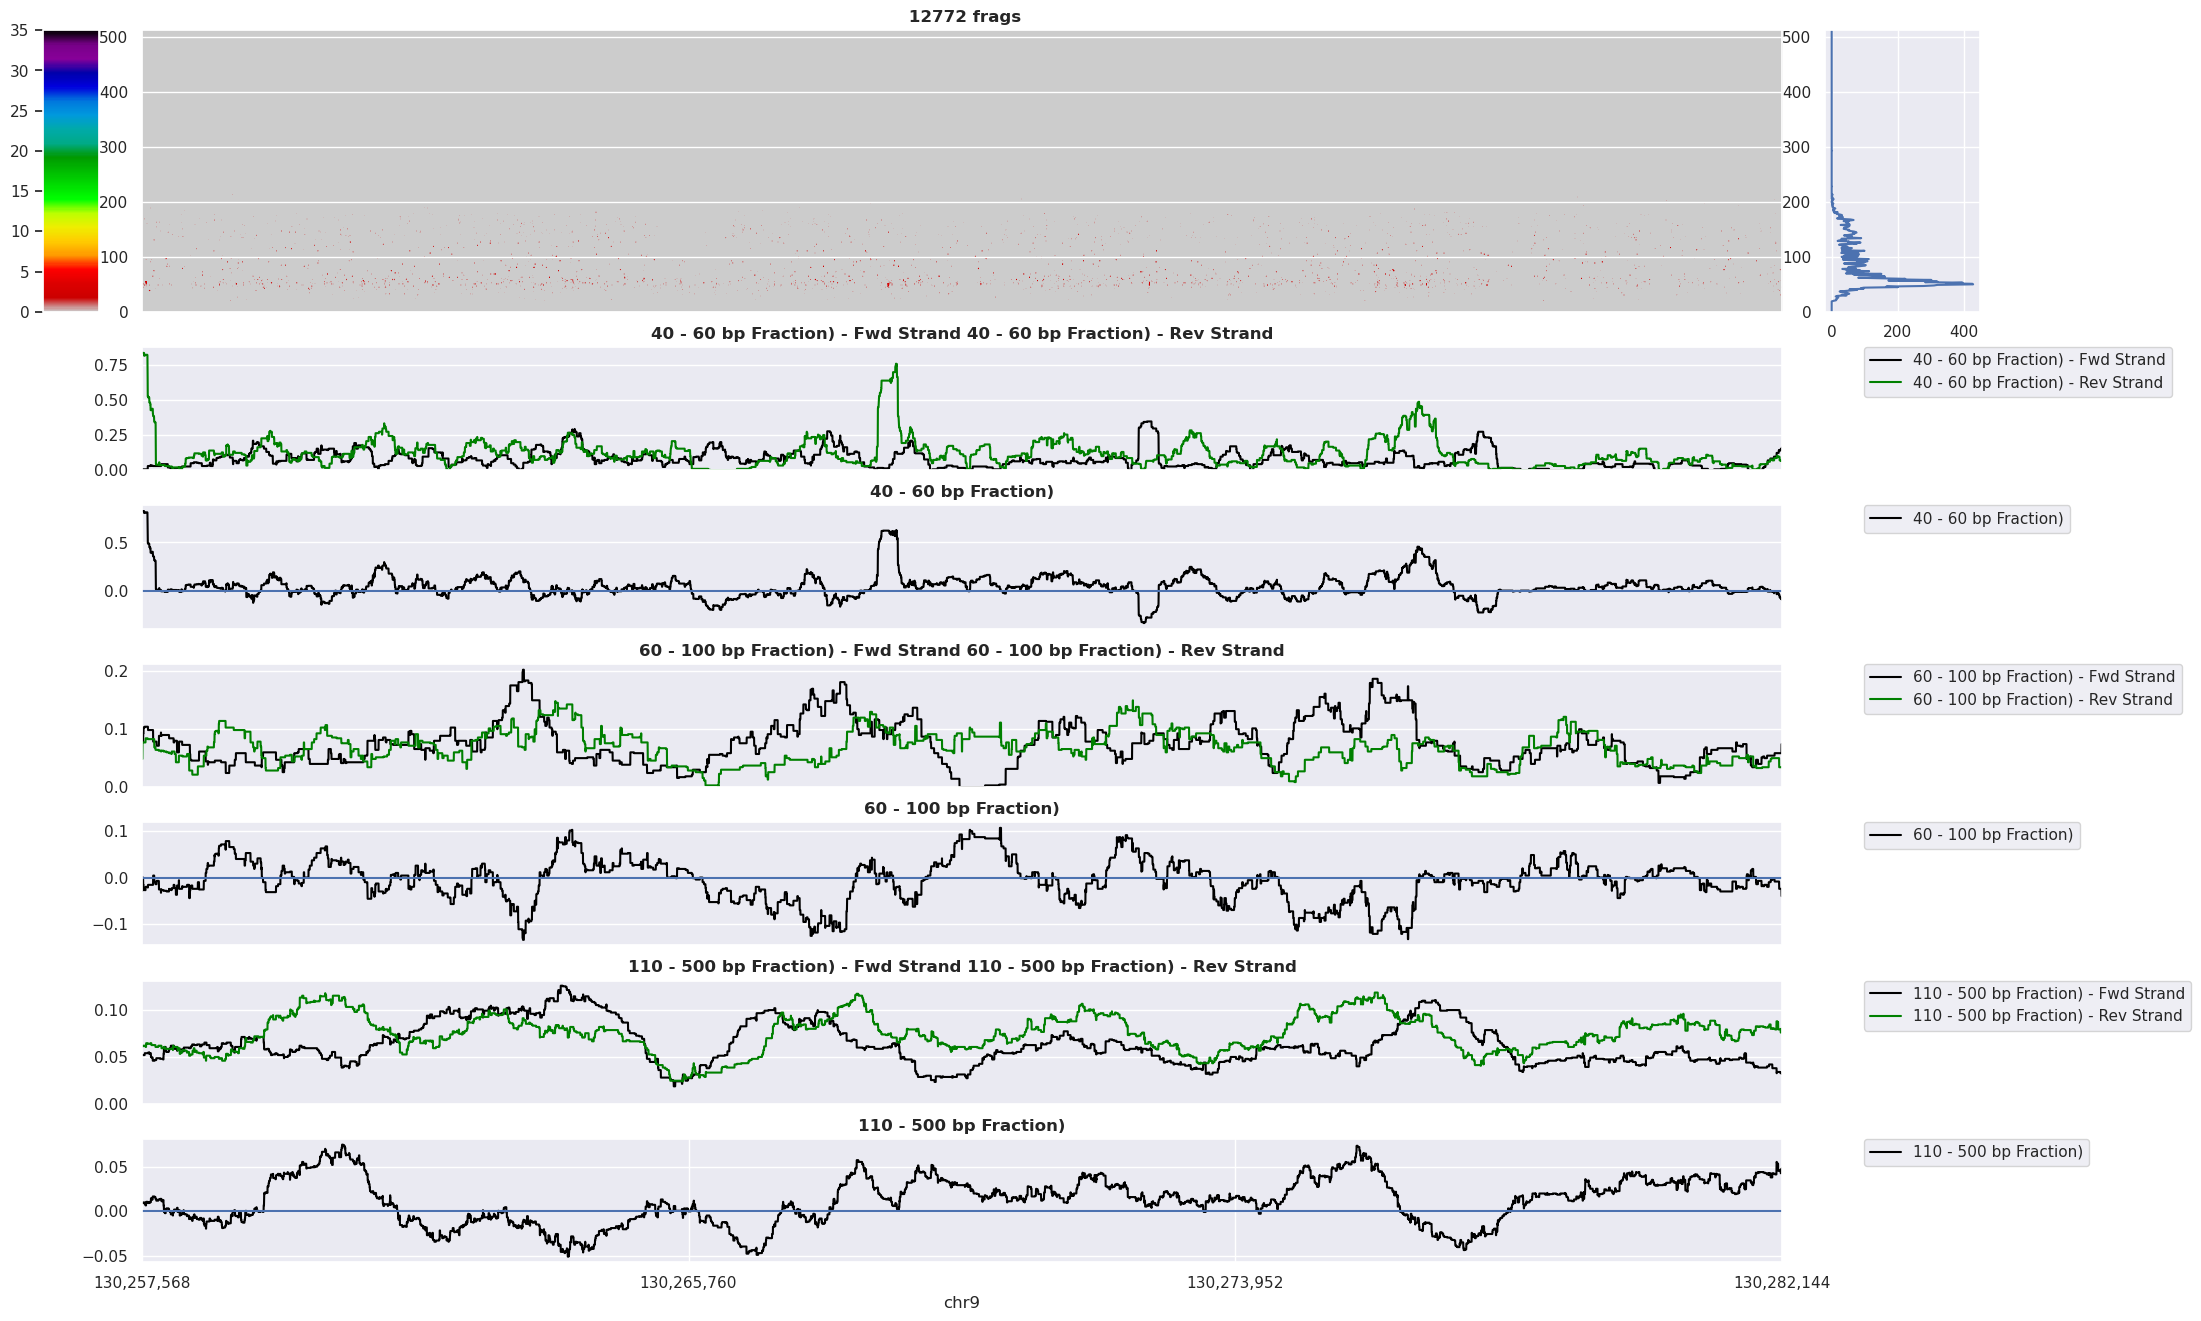

In [303]:
make_tracks_coverage_tracks(expression_rdf.query("gene_name.str.startswith(@GENE_NAME) and label == 1"), 'tss').plot()

# RPM Exploration

In [226]:
from seaborn import stripplot, boxplot
scores = scores.reset_index().set_index('sample_id').join(scores.groupby('sample_id').n_fragments.sum().rename('total_n_fragments')).reset_index()
scores['rpm'] = 1000000*scores.n_fragments/scores.total_n_fragments
on_gi_off_blood_srdf = scores.query("blood_expression < 1e-6 and gi_expression > 10").rename(columns={'gi_expression': 'expression'})
on_gi_off_blood_srdf

# .query("gene_name.str.startswith('CKMT')")
boxplot(data=on_gi_off_blood_srdf.query("gene_name.str.startswith('NOX1')").groupby(['label', 'sample_id'])[['rpm']].sum().reset_index(), x='label', y='rpm')
stripplot(data=on_gi_off_blood_srdf.query("gene_name.str.startswith('NOX1')").groupby(['label', 'sample_id'])[['rpm']].sum().reset_index(), x='label', y='rpm')

ValueError: columns overlap but no suffix specified: Index(['total_n_fragments'], dtype='object')